# Predicting Customer Dissatisfaction Before It's Posted

*Binary classification on 99k Brazilian e-commerce orders (Olist).*

Notebook 1 of the planned series, covering the EDA. The goal is; understand the data well enough to know which features are worth building, where to draw the line between a good and a bad review (split), and which factors a business could actually fix. Modelling is not the only goal.

The analysis runs in five passes: check the shape, check the quality, look at each feature on its own, look at each feature against the target, then look at the features together. 

This covers univariate, bivariate as well as multivariate analysis.

## Problem statement

The goal is to predict whether a delivered order will get a bad review, and to identify which factors drive it.

The prediction happens at one specific moment: the order has just been delivered and the customer has not written a review yet. Anything created after that moment is off limits, because the model would not have it when it needs to make the call. 

That rules out variables such as the review text/comments and both review timestamps.

Two outputs come from the same analysis:

1. A predicted probability for each delivered order, which ranks orders by how likely they are to get a bad review.
2. A ranked list of which factors drive bad reviews, and which of those a business can actually control.

The second output is the more useful of the two. A probability tells you which orders look risky. 

One row is one order(grain). The target is `review_score`, collapsed into good and bad. The cut-off is not set yet. It gets decided later in this notebook, once the score distribution and its relationship to the features are clear.

## Modeling population

The modeling population is delivered orders only.

An order that was cancelled or never arrived is close to guaranteed a bad review. The data confirms this further down: 71% of failed orders got one star. A model trained on those rows learns that cancelled means bad, scores well, and tells the business nothing it did not already know.

A second reason matters more. Those rows are easy to predict, so keeping them would push accuracy up without the model getting any better at the cases that count. The metrics would be flattering rather than useful.

The harder question is the interesting one: why did an order that actually arrived still get rated badly? A team can act on that.

Two things get checked before the filter is applied, both further down:

- How much data the filter costs. Dropping rows is only cheap when there are few of them.
- Whether failed orders really are almost all bad reviews. If so, they carry no useful signal and are safe to remove.

Both checks support the filter, so it is applied in the cleaning step.

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
DATA_DIR = "../data/raw/"

## Understanding the data

The data arrives as eight separate CSV files. Each one gets checked for row and column counts, missing values, and how it joins to the others.

### Load the tables

In [ ]:

df_customers = pd.read_csv(DATA_DIR + "olist_customers_dataset.csv")
df_geolocation = pd.read_csv(DATA_DIR + "olist_geolocation_dataset.csv")
df_order_items = pd.read_csv(DATA_DIR + "olist_order_items_dataset.csv")
df_order_payments = pd.read_csv(DATA_DIR + "olist_order_payments_dataset.csv")
df_order_reviews = pd.read_csv(DATA_DIR + "olist_order_reviews_dataset.csv")
df_orders = pd.read_csv(DATA_DIR + "olist_orders_dataset.csv")
df_products = pd.read_csv(DATA_DIR + "olist_products_dataset.csv")
df_sellers = pd.read_csv(DATA_DIR + "olist_sellers_dataset.csv")

### Size and missing values

One table comparing all eight, rather than eight separate summaries.

In [ ]:
tables = {
    "customers": df_customers,
    "geolocation": df_geolocation,
    "order_items": df_order_items,
    "order_payments": df_order_payments,
    "order_reviews": df_order_reviews,
    "orders": df_orders,
    "products": df_products,
    "sellers": df_sellers,
}

profile = []

for name in tables:
    df = tables[name]
    profile.append(
        {
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "null_cells": df.isnull().sum().sum(),
            "columns_with_nulls": (df.isnull().sum() > 0).sum(),
        }
    )

profile = pd.DataFrame(profile)
profile

,table,rows,columns,null_cells,columns_with_nulls
0,customers,99441,5,0,0
1,geolocation,1000163,5,0,0
2,order_items,112650,7,0,0
3,order_payments,103886,5,0,0
4,order_reviews,99224,7,145903,2
5,orders,99441,8,4908,3
6,products,32951,9,2448,8
7,sellers,3095,4,0,0


Three things stand out.

`geolocation` is by far the largest table at one million rows, and it maps zip codes to coordinates rather than holding anything tied to an order.

`order_reviews` has the most missing data by a wide margin, but all of it sits in the two comment columns. The review score itself is complete, which is what matters since it is the target.

`orders` has missing values in three of its date columns. These are most likely orders that never finished, and the missing values section covers that.

### Preview the rows

A first look at the columns in each table, before working out how they join.

In [ ]:
display("Orders:", df_orders.head(3))
display("Order Items:", df_order_items.head(3))
display("Order Payments:", df_order_payments.head(3))
display("Order Reviews:", df_order_reviews.head(3))
display("Customers:", df_customers.head(3))
display("Sellers:", df_sellers.head(3))
display("Products:", df_products.head(3))

'Orders:'

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


'Order Items:'

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


'Order Payments:'

...

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


'Sellers:'

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


'Products:'

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


### How the tables connect (a guess, not yet checked)

This join map is a guess, built from shared column names and the row count gaps. Nothing here is verified yet. That is the job of the quality checks below.

- orders to customers: `customer_id`, one to one.
- orders to order_items: `order_id`, probably one to many, since order_items has more rows (112,650) than orders (99,441).
- orders to order_payments: `order_id`, probably one to many as well. An order can be paid in more than one way.
- orders to order_reviews: `order_id`. The row counts are close but not equal, so counts alone settle nothing here.
- order_items to products: `product_id`.
- order_items to sellers: `seller_id`.

The `geolocation` table is left out. It maps zip codes to coordinates, and the location detail this project needs is already in the customers and sellers tables as city and state. Leaving it out keeps the merge simpler.

### Converting the date columns

The five date columns in `orders` load as text, so no date maths is possible on them yet. They get converted here, once, so the ordering check below works and the feature work later does not have to repeat it.

The missing counts are printed before and after. A value that fails to convert becomes a null, so a jump in the null count would mean some dates use a format pandas did not expect.

In [ ]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

print("missing before conversion:")

print(df_orders[date_cols].isnull().sum())

for col in date_cols:
    df_orders[col] = pd.to_datetime(df_orders[col])

print('')

print("missing after conversion:")

print(df_orders[date_cols].isnull().sum())

print('')

print("date range:", df_orders["order_purchase_timestamp"].min(), "to", df_orders["order_purchase_timestamp"].max())

missing before conversion:
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

missing after conversion:
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

date range: 2016-09-04 21:15:19 to 2018-10-17 17:30:18


The counts match exactly before and after, so every value parsed correctly and no dates use an unexpected format. The missing values were already missing in the raw file.

Purchases run from September 2016 to October 2018, which is a little over two years. That has two consequences worth noting now.

The first is that seasonality is worth checking. Two years is enough to see whether order volume and review scores move with the time of year.

The second matters more. Because the data covers a long stretch of time, splitting it randomly into training and test sets would put later orders into the training set and earlier orders into the test set. The model would effectively be learning from the future to predict the past, which inflates its scores and would not be possible in real use. 

The train test split can be time based instead, and the section below checks whether the data is stable enough for that to work.

The missing dates line up with the pattern expected from unfinished orders: 160 never approved, 1,783 never handed to a carrier, 2,965 never delivered. Each stage has more missing values than the one before it. 

The missing values will also check and confirms this with `order_status`.

### Do the timestamps run in the right order?

Each order moves through four dates in a fixed order: purchased, approved, handed to the carrier, delivered. A fifth date, the estimated delivery date, is set at purchase.

Timestamps outside of this out of order can looks valid but is not. 

therefore the three checks catch impossible sequences before any feature gets built on top of them.

In [ ]:
bad_approved = (df_orders["order_approved_at"] < df_orders["order_purchase_timestamp"]).sum()
bad_carrier = (df_orders["order_delivered_carrier_date"] < df_orders["order_approved_at"]).sum()
bad_delivered = (df_orders["order_delivered_customer_date"] < df_orders["order_delivered_carrier_date"]).sum()

print("approved before purchase:", bad_approved)
print("handed to carrier before approved:", bad_carrier)
print("delivered before handed to carrier:", bad_delivered)

approved before purchase: 0
handed to carrier before approved: 1359
delivered before handed to carrier: 23


Two of the three checks found problems.

Zero orders were approved before they were purchased, so the start of the sequence is sound.
1,359 orders were handed to the carrier before the payment was approved this is fine since ; `order_approved_at` records when the payment system confirmed, and for some payment types confirmation can take time and meanwhile the seller may ship; like Brazilian boleto payments are a bank slip rather than an instant card charge, so a delay there is possible. 

The problem there is that any feature measuring the gap between approval and carrier pickup will be negative for these 1,359 orders, must get handled before theappropriate feature construction takes place.

23 orders were delivered before they were handed to the carrier. That has no sensible explanation. A package cannot arrive before it ships, so these are broken records. At 23 rows out of 99,441 they are small enough to drop, and they get removed in the cleaning step.

## Data quality checks

Three checks, each answering a different question. 

Are there duplicate rows? 

Is each table's key unique? 

And do the keys in one table actually exist in the table they point to?

In [ ]:
for name in tables:
    print(name, "duplicate rows:", tables[name].duplicated().sum())

customers duplicate rows: 0
geolocation duplicate rows: 261831
order_items duplicate rows: 0
order_payments duplicate rows: 0
order_reviews duplicate rows: 0
orders duplicate rows: 0
products duplicate rows: 0
sellers duplicate rows: 0


This check looks for rows identical across every column, not just a repeated key. It catches a file loaded twice, which a key check on its own would miss.

Zero duplicate rows across all eight tables.

In [ ]:
print("customer_id in customers:", df_customers["customer_id"].is_unique)
print("order_id in orders:", df_orders["order_id"].is_unique)
print("product_id in products:", df_products["product_id"].is_unique)
print("seller_id in sellers:", df_sellers["seller_id"].is_unique)
print("order_id in order_reviews:", df_order_reviews["order_id"].is_unique)
print("order_id in order_items:", df_order_items["order_id"].is_unique)
print("order_id in order_payments:", df_order_payments["order_id"].is_unique)

customer_id in customers: True
order_id in orders: True
product_id in products: True
seller_id in sellers: True
order_id in order_reviews: False
order_id in order_items: False
order_id in order_payments: False


`customers`, `orders`, `products`, and `sellers` each have a unique key, so they merge onto orders directly without changing the row count.

`order_items` and `order_payments` both have repeated `order_id` values, confirming the one to many guess. cant merge onto orders directly without breaking the our grain: 1 row per order, so both get aggregated to order level first.

`order_id` in `order_reviews` is not unique either, which is unexpected. Reviews should be one per order to make the predictions. This affects the target, so it must be checked too

In [ ]:
print("orders.customer_id exists in customers:", df_orders["customer_id"].isin(df_customers["customer_id"]).all())
print("order_items.order_id exists in orders:", df_order_items["order_id"].isin(df_orders["order_id"]).all())
print("order_payments.order_id exists in orders:", df_order_payments["order_id"].isin(df_orders["order_id"]).all())
print("order_reviews.order_id exists in orders:", df_order_reviews["order_id"].isin(df_orders["order_id"]).all())
print("order_items.product_id exists in products:", df_order_items["product_id"].isin(df_products["product_id"]).all())
print("order_items.seller_id exists in orders:", df_order_items["seller_id"].isin(df_sellers["seller_id"]).all())

orders.customer_id exists in customers: True
order_items.order_id exists in orders: True
order_payments.order_id exists in orders: True
order_reviews.order_id exists in orders: True
order_items.product_id exists in products: True
order_items.seller_id exists in orders: True


All six come back True. Every key that points from one table to another lands on a real row, with no orphans.

This matters because I am about to merge with `how="left"`. A left join hides broken keys as nulls rather than raising an error, so without this check I would find out about a problem later and mistake it for missing data.

Combined with the uniqueness results above, the join map is now verified rather than guessed.

### Checking the target: orders and order_reviews

`review_score` is what I am predicting, so I check this join before the others. If reviews are missing for some orders I lose training rows, and if they are duplicated for others I count the same order twice. Both are worse than getting a feature slightly wrong.

In [ ]:
print("rows in order_reviews:", len(df_order_reviews))
print("unique order_id in order_reviews:", df_order_reviews["order_id"].nunique())
print("unique order_id in orders:", df_orders["order_id"].nunique())
print("duplicated order_id in order_reviews:", df_order_reviews["order_id"].duplicated().sum())
print("\nmissing values in order_reviews:")
print(df_order_reviews.isnull().sum())

rows in order_reviews: 99224
unique order_id in order_reviews: 98673
unique order_id in orders: 99441
duplicated order_id in order_reviews: 551

missing values in order_reviews:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


Two problems, both small.

99,441 orders exist but only 98,673 of them have a review, so 768 orders have no score at all. I cannot train on those and they get dropped in the cleaning step.

551 orders have more than one review row. `review_score` itself is never missing, so the target is complete for every order that has a review. The two comment columns are mostly empty, which is expected. Most people leave a star rating and dont bother to leave a comment

Before I decide what to do about the duplicates, i must check

### Do the duplicate reviews agree?

551 orders have more than one review. I plan to keep one review per order.

If both reviews give the same score, the choice is harmless anything. If they give different scores, then I am choosing the label myself, and that is worth knowing about since the label is what the whole model is trained on.

In [ ]:
dupe_mask = df_order_reviews["order_id"].duplicated(keep=False)
dupe_reviews = df_order_reviews[dupe_mask]

# for each affected order, how many different scores did it receive? 
scores_per_order = dupe_reviews.groupby("order_id")["review_score"].nunique()

print("orders with more than one review:", len(scores_per_order))
print("number of different scores given per order:")
print(scores_per_order.value_counts())

orders with more than one review: 547
number of different scores given per order:
review_score
1    345
2    202
Name: count, dtype: int64


345 had only 1 unique value meaning review_score for these are the same during dedupe we can choose any method for this wont cause any problems

202 values are ambiguous since they had 2 different review scores

In [ ]:
# 1. Filter dataset to orders that have conflicting review scores
disagreeing_order_ids = scores_per_order[scores_per_order > 1].index
disagreeing_reviews = dupe_reviews[dupe_reviews["order_id"].isin(disagreeing_order_ids)]

# 2. Get the lowest and highest score for each conflicting order
review_summary = disagreeing_reviews.groupby("order_id")["review_score"].agg(
    lowest_score="min",
    highest_score="max"
)

# 3. Calculate how far apart the ratings are (e.g., 5-star vs 1-star = gap of 4)
review_summary["score_gap"] = review_summary["highest_score"] - review_summary["lowest_score"]

print("Frequency of rating gaps between reviews for the same order:")
print(review_summary["score_gap"].value_counts().sort_index())

# 4. Check if the reviews conflict on sentiment (Good: 4–5 stars and Bad: 1–3 stars)
lowest_is_good = review_summary["lowest_score"] >= 4
highest_is_good = review_summary["highest_score"] >= 4

# Count orders where one review is "Good" and another is "Bad"
sentiment_conflicts = (lowest_is_good != highest_is_good).sum()

print("Orders where reviews flip overall sentiment (Good vs Bad):", sentiment_conflicts)

Frequency of rating gaps between reviews for the same order:
score_gap
1    90
2    47
3    32
4    33
Name: count, dtype: int64
Orders where reviews flip overall sentiment (Good vs Bad): 118


Of the 547 orders with more than one review, 345 received the same score twice and 202 received different scores.

Looking at how far apart the disagreements are: 90 differ by one star, and 33 differ by four stars, meaning the same order received both a 1 and a 5. That is a wide gap for a single purchase.

The number that matters is the last one. Under the good and bad split used later in this notebook, 118 of these orders would land in a different class depending on which review is kept. For those orders the label is not being read from the data, it is being chosen here.

118 orders out of roughly 96,000 is around 0.1% of the modeling population, so this is not large enough to affect the model

**Decision: keep the most recent review per order.** because domain understanding is The later review is the customer's final position.

Dropping all 547 orders loses valid data for the 345 that agree.

### How many customers order more than once?

In [ ]:
print("rows in customers:", len(df_customers))
print("unique people:", df_customers["customer_unique_id"].nunique())

rows in customers: 99441
unique people: 96096


Almost every customer appears only once. There is no repeat customer behavior here to be learnt from the model

It also means I do not have to worry about the same customer appearing in both the training and test sets, which would otherwise let the model learn a specific person's patterns rather than a general pattern. Model learns general patterns that apply for unseen buyers too.

### Table relationships (verified)

![Table relationships](assets/table_relationships.png)

Green edges are one to one or many to one, so those tables merge onto orders directly. Orange edges are one to many, so `order_items` and `order_payments` get summarised to order level first.

## Merging the tables

The target grain is one row per order. `order_items` and `order_payments` hold several rows per order, so both get summarised to order level before anything is merged onto `orders`.

Every merge is followed by an assertion on the row count. A left join with a repeated key silently multiplies rows, and the resulting table still looks reasonable, so the check has to be explicit.

### Add product and seller details to items

`product_id` and `seller_id` are both many to one relative to `order_items`, verified above, so this merge adds columns without adding rows.

In [ ]:
items_enriched = pd.merge(df_order_items, df_products, on="product_id", how="left")
items_enriched = pd.merge(items_enriched, df_sellers, on="seller_id", how="left")

print("Did merge changed the row count: ", (len(items_enriched) != len(df_order_items))) 
print("items_enriched shape:", items_enriched.shape)

Did merge changed the row count:  False
items_enriched shape: (112650, 18)


### Summarise items to order level

Each order can hold several items, so the item columns get collapsed into one row per order. Sums for the money and weight columns, counts for the item and product columns, and the most common value for the two category columns.

`product_category_name` becomes `main_category`. An order can contain items from more than one category, so this takes whichever appears most often. The same applies to `seller_state`, which is needed later to compare the customer's state against the seller's.

In [ ]:
order_items_summary = (
    items_enriched.groupby("order_id")
    .agg(
        total_items_value=("price", "sum"),
        total_freight=("freight_value", "sum"),
        num_items=("product_id", "count"),
        num_unique_products=("product_id", "nunique"),
        num_unique_sellers=("seller_id", "nunique"),
        total_weight_g=("product_weight_g", "sum"),
        # most common category and seller state, since an order can span several
        main_category=(
            "product_category_name",
            lambda x: x.mode().iloc[0] if x.mode().size > 0 else np.nan,
        ),
        seller_state_mode=(
            "seller_state",
            lambda x: x.mode().iloc[0] if x.mode().size > 0 else np.nan,
        ),
    )
    .reset_index()
)

print("order_items_summary shape:", order_items_summary.shape)
order_items_summary.head(3)

order_items_summary shape: (98666, 9)


,order_id,total_items_value,total_freight,num_items,num_unique_products,num_unique_sellers,total_weight_g,main_category,seller_state_mode
0,00010242fe8c5a6d1ba2dd792cb16214,58.9,13.29,1,1,1,650.0,cool_stuff,SP
1,00018f77f2f0320c557190d7a144bdd3,239.9,19.93,1,1,1,30000.0,pet_shop,SP
2,000229ec398224ef6ca0657da4fc703e,199.0,17.87,1,1,1,3050.0,moveis_decoracao,MG


98,666 rows, not 99,441. This table only holds a row for orders that had at least one item, so 775 orders are missing entirely. so we can expect them to become nulls after the merge, and the missing values section will explain more.

### Summarise payments to order level

An order can be paid in more than one way, so the payment rows get collapsed the same way. Total paid, the most common payment method, and the highest number of installments.

In [ ]:
order_payments_summary = (
    df_order_payments.groupby("order_id")
    .agg(
        total_payment_value=("payment_value", "sum"),
        max_payment_installments=("payment_installments", "max"),
        payment_type_mode=(
            "payment_type",
            lambda x: x.mode().iloc[0] if x.mode().size > 0 else np.nan,
        ),
    )
    .reset_index()
)

print("order_payments_summary shape:", order_payments_summary.shape)
order_payments_summary.head(3)

order_payments_summary shape: (99440, 4)


,order_id,total_payment_value,max_payment_installments,payment_type_mode
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card


### Keep one review per order

As decided above, the most recent review is kept for each order.

In [ ]:
df_reviews_deduped = (
    df_order_reviews.sort_values("review_answer_timestamp").drop_duplicates(subset=["order_id"], keep="last")
)

print("reviews before dedupe:", len(df_order_reviews))
print("reviews after dedupe:", len(df_reviews_deduped))
print("still more than one review per order", not df_reviews_deduped["order_id"].is_unique)

reviews before dedupe: 99224
reviews after dedupe: 98673
still more than one review per order False


### Build the order level table

Four left joins onto `orders`. Left rather than inner, so nothing silently disappears. Missing values get handled deliberately in the next section instead.

In [ ]:
df_merged = pd.merge(df_orders, df_customers, on="customer_id", how="left")
df_merged = pd.merge(df_merged, df_reviews_deduped, on="order_id", how="left")
df_merged = pd.merge(df_merged, order_items_summary, on="order_id", how="left")
df_merged = pd.merge(df_merged, order_payments_summary, on="order_id", how="left")

assert len(df_merged) == len(df_orders), "a merge multiplied rows"
assert df_merged["order_id"].is_unique, "order_id is no longer unique"

print("df_merged shape:", df_merged.shape)

df_merged shape: (99441, 29)


Both assertions pass, so the merges added columns without duplicating any order. One row per order still holds.

## Missing values


In [ ]:
missing = df_merged.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

review_comment_title             87891
review_comment_message           58666
order_delivered_customer_date     2965
main_category                     2164
order_delivered_carrier_date      1783
total_weight_g                     775
seller_state_mode                  775
total_freight                      775
num_items                          775
num_unique_sellers                 775
num_unique_products                775
total_items_value                  775
review_answer_timestamp            768
review_id                          768
review_score                       768
review_creation_date               768
order_approved_at                  160
total_payment_value                  1
max_payment_installments             1
payment_type_mode                    1
dtype: int64


The gaps fall into four groups.

**No label.** 768 orders have no `review_id` or `review_score`. Nothing to train on, so these get dropped.

**No items.** 775 orders are missing every item column, meaning they have no matching row in `order_items` at all. Worth investigating, since the pattern suggests these orders never shipped.

**No category.** 2,164 orders are missing `main_category`, which is more than the 775 with no items. So some orders do have items where every item is missing its category label. Also worth a look.

**Unfinished orders.** `order_approved_at` (160), `order_delivered_carrier_date` (1,783), and `order_delivered_customer_date` (2,965) note that they were already missing in the raw orders file, and not caused by any merge. 

The counts rise at each stage as we observed beofre, these are the orders that stopped partway before it was completed.

The two comment columns are mostly empty, as expected. Most customers leave a star rating with no text. Free text is out of scope for this project, so those columns get dropped.

In [ ]:
no_items = df_merged[df_merged["num_items"].isnull()]

print("order status of the 775 orders with no items:")
print(no_items["order_status"].value_counts())

print()
print("review scores of those same orders:")
print(no_items["review_score"].value_counts(dropna=False))

order status of the 775 orders with no items:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

review scores of those same orders:
review_score
1.0    539
5.0     70
2.0     62
3.0     53
4.0     32
NaN     19
Name: count, dtype: int64


603 unavailable plus 164 cancelled accounts for 767 of the 775. These orders never shipped, so there is nothing in `order_items` for them. The remaining 8 got further along but still have no item rows, which is a small problem not worth chasing.

Their review scores split into two groups. 

19 have no score at all, and these are part of the 768 unlabelled orders already identified rather than extra ones nothing special. 

The other 756 HAVE a score, and it is heavily skewed: 539 of 756, or 71%, are one star.

That 71% is the evidence promised in the population section at the top. Failed orders are almost always rated badly, which is common sense rather than insight. Knowing that a cancelled order gets a bad review does not help anyone do anything differently, thats why our business problem focuses on the delivered orders since getting bad reviews on a delivered order is something we can act on.

### Orders with items but no category

The 2,164 missing categories split into two groups. The 775 with no items at all are already explained. but those 1,389 orders that do have items where but missing its category.

These need checking before being filled with a placeholder.

In [ ]:
has_items_no_category = df_merged["main_category"].isnull() & df_merged["num_items"].notnull()
category_gap = df_merged[has_items_no_category]

print("orders with items but no category:", len(category_gap))
print("order status:")
print(category_gap["order_status"].value_counts())
print("review score share:")
print(category_gap["review_score"].value_counts(normalize=True).sort_index().round(3))

orders with items but no category: 1389
order status:
order_status
delivered     1332
shipped         24
canceled        14
processing      12
invoiced         7
Name: count, dtype: int64
review score share:
review_score
1.0    0.154
2.0    0.033
3.0    0.065
4.0    0.199
5.0    0.548
Name: proportion, dtype: float64


1,332 of the 1,389, or 96%, are delivered. These are real orders that reached the customer.

Their review scores confirm it: 55% are five star and around 75% are four or five star, close to the overall spread and nothing like the 71% one star skew of the failed group above.

So this is a plain metadata gap. The order happened normally and only the product's category label is missing from the products table. Filling it with `"unknown"` is safe, since it will not disguise a failed order as a normal one.

The 21 cancelled, processing and invoiced orders in this group are removed by the delivered filter anyway.

### What the delivered filter costs

The skew is proven. The remaining question from the population section is the cost. Excluding failed orders is only sensible if there are few of them.

In [ ]:
print(df_merged["order_status"].value_counts(normalize=True).round(3))

order_status
delivered      0.970
shipped        0.011
canceled       0.006
unavailable    0.006
invoiced       0.003
processing     0.003
created        0.000
approved       0.000
Name: proportion, dtype: float64


Delivered orders are 97% of the data, so the filter costs very little. Skew proven and cost confirmed, so the filter is applied in the cleaning step below.

## Cleaning


The order matters. Rows get dropped first and gaps get filled last, so no effort goes into filling values on rows that are about to be removed.

1. Drop orders with no review score. No label means nothing to train on.
2. Drop the 23 orders with impossible timestamps, identified above
3. Filter to delivered orders, applying the population decision from the top of the notebook.
4. Fill the gaps that remain.
5. Drop columns that are out of scope.

Step 3 also removes every no-item order in one go, since all of those were cancelled or unavailable. So there is no need for a further investigation or flag marking orders with no items for the model to learn, or anything similar because after this filter none remain.

In [ ]:
df_clean = df_merged.copy()
print("starting rows:", len(df_clean))

# 1. no label, nothing to train on
df_clean = df_clean.dropna(subset=["review_score"])
print("after dropping orders with no review:", len(df_clean))

# 2. impossible timestamps: delivered before being handed to the carrier
broken_dates = df_clean["order_delivered_customer_date"] < df_clean["order_delivered_carrier_date"]
df_clean = df_clean[~broken_dates]
print("after dropping impossible timestamps:", len(df_clean))

# 3. the modeling population
df_clean = df_clean[df_clean["order_status"] == "delivered"]
print("after filtering to delivered orders:", len(df_clean))

starting rows: 99441
after dropping orders with no review: 98673
after dropping impossible timestamps: 98650
after filtering to delivered orders: 95809


In [ ]:
missing = df_merged.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

review_comment_title             87891
review_comment_message           58666
order_delivered_customer_date     2965
main_category                     2164
order_delivered_carrier_date      1783
total_weight_g                     775
seller_state_mode                  775
total_freight                      775
num_items                          775
num_unique_sellers                 775
num_unique_products                775
total_items_value                  775
review_answer_timestamp            768
review_id                          768
review_score                       768
review_creation_date               768
order_approved_at                  160
total_payment_value                  1
max_payment_installments             1
payment_type_mode                    1
dtype: int64


In [ ]:
# 4. fill the gaps that remain on delivered orders
item_cols = [
    "total_items_value",
    "total_freight",
    "num_items",
    "num_unique_products",
    "num_unique_sellers",
    "total_weight_g",
]
payment_cols = ["total_payment_value", "max_payment_installments"]

df_clean[item_cols] = df_clean[item_cols].fillna(0)
df_clean[payment_cols] = df_clean[payment_cols].fillna(0)
df_clean["main_category"] = df_clean["main_category"].fillna("unknown")
df_clean["payment_type_mode"] = df_clean["payment_type_mode"].fillna("unknown")

# 5. out of scope columns
drop_cols = [
    "order_status",              # constant after the filter, so it carries no information
    "review_comment_title",      # free text, out of scope
    "review_comment_message",    # free text, out of scope
    "review_creation_date",       # created after the prediction moment
    "review_answer_timestamp",    # created after the prediction moment
    "customer_city",              # too granular, customer_state covers geography
]
df_clean = df_clean.drop(columns=drop_cols)

print("final shape:", df_clean.shape)
print("remaining nulls:")
remaining = df_clean.isnull().sum()
print(remaining[remaining > 0])

final shape: (95809, 23)
remaining nulls:
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
dtype: int64


`order_status` is dropped because every remaining row says "delivered", so the column is constant and cannot tell the model anything.

The two review timestamps are dropped for a different reason. Both are created after the review is written, which is after the prediction moment, so a model using them would be using information it could not have in real use.

The numeric fills use 0 as a safety step. After the delivered filter there should be nothing left to fill, since every no-item order was cancelled or unavailable, but the fill guards against anything unexpected.

Any remaining nulls are in the date columns, which is expected. Those are handled in the next section, when the date features get built.

The cleaning steps cost 3,632 rows in total, or 3.7% of the data.

The largest drop by far is the delivered filter at 2,841 rows, which matches the 97% delivered share seen above. The 768 unlabelled orders and 23 broken records are small by comparison.

All 23 impossible-timestamp rows turned out to be delivered orders, so every one of them would have entered the model had the ordering check not been run.

The modeling population is 95,809 delivered, labelled orders across 23 columns.

Three date columns still hold a handful of nulls: 14 missing an approval date, 2 missing a carrier pickup date, and 8 missing a delivery date. These are handled in the next section, where they matter for the first time.

### A column for bad reviews

The threshold between good and bad is decided later in this notebook, so this cannot be set yet. It gets added at that point, along with the reasoning.

## Building features for the analysis

The raw date columns cannot be compared against review score directly. A timestamp is not something a model can use, so the durations between timestamps have to be built first.

These are exploratory versions. The final versions, including how nulls and edge cases get handled, are built in notebook 2. The purpose here is narrower: work out which of these relate to review score at all, so notebook 2 only builds the ones worth building.

### Delivery time and lateness

`delivery_days` is the obvious starting point: how long the order took from purchase to arrival.

we must be careful as it has a problem though. Twelve days to a different state is normal. Twelve days across same state is a failure. The same number means different things depending on where the order was going same state or outside.

Olist already accounts for distance when it gives the customer an estimated delivery date, setting a longer estimate for far-away addresses on purpose. So the gap between the promised date and the real one measuress this better:

`days_late = delivered date - estimated date`

Negative means early, zero means on time, positive means late. Both features get built so they can be compared directly.

from the same dates we create `is_late` a simple yes or no flag, helps in analysis grouping.

 `promise_window_days` is the length of the promise itself, which matters because Olist sets it and could change it.

In [ ]:
df_clean["delivery_days"] = (
    df_clean["order_delivered_customer_date"] - df_clean["order_purchase_timestamp"]
).dt.days

df_clean["days_late"] = (
    df_clean["order_delivered_customer_date"] - df_clean["order_estimated_delivery_date"]
).dt.days

df_clean["is_late"] = (df_clean["days_late"] > 0).astype(int)

df_clean["promise_window_days"] = (
    df_clean["order_estimated_delivery_date"] - df_clean["order_purchase_timestamp"]
).dt.days

print(df_clean[["delivery_days", "days_late", "promise_window_days"]].describe().round(3))

       delivery_days  days_late  promise_window_days
count      95801.000  95801.000            95809.000
mean          12.054    -11.910               23.367
std            9.466     10.109                8.753
min            0.000   -147.000                2.000
25%            6.000    -17.000               18.000
50%           10.000    -12.000               23.000
75%           15.000     -7.000               28.000
max          208.000    188.000              155.000


In [ ]:
print("percentage of orders arriving late:", df_clean["is_late"].mean().round(4))

percentage of orders arriving late: 0.0666


### Where the delay happens

`delivery_days` covers the whole journey, which means a slow order looks the same whether its sellers or carriers fault so lets split

Splitting it separates the two, and they belong to different people. `seller_handling_days` is a seller performance problem. 

`carrier_transit_days` is a logistics problem. If one of them drives bad reviews far more than the other, that changes who needs to fix it.

In [ ]:
df_clean["seller_handling_days"] = (
    df_clean["order_delivered_carrier_date"] - df_clean["order_approved_at"]
).dt.days

df_clean["carrier_transit_days"] = (
    df_clean["order_delivered_customer_date"] - df_clean["order_delivered_carrier_date"]
).dt.days

print("seller_handling_days:")
print(df_clean["seller_handling_days"].describe().round(2))

print("carrier_transit_days:")
print(df_clean["carrier_transit_days"].describe().round(2))


seller_handling_days:
count    95793.00
mean         2.29
std          3.53
min       -172.00
25%          0.00
50%          1.00
75%          3.00
max        125.00
Name: seller_handling_days, dtype: float64
carrier_transit_days:
count    95800.00
mean         8.85
std          8.66
min          0.00
25%          4.00
50%          7.00
75%         12.00
max        205.00
Name: carrier_transit_days, dtype: float64


### A problem with seller_handling_days

1,343 orders show a negative handling time, meaning the package reached the carrier before the
payment was recorded as approved. That is 1.4% of the modeling population, and it matches the
1,359 found in the timestamp ordering check earlier.

This is a recording issue rather than a physical impossibility. one hypothesis is that `order_approved_at` logs when the
payment system confirmed, and for some payment methods that confirmation lags behind the seller
starting to ship. Brazilian boleto payments are a bank slip rather than an instant card charge,
so a delay there is plausible. The check below tests that explanation instead of leaving it as a
guess.

The consequence is that for these orders the feature does not measure what it claims to. A
negative handling time is not a fast seller, it is a late approval timestamp.

**Decision: keep the rows and treat the negative values as missing when this feature is used for the analysis below.**
Dropping the orders would remove 1,343 valid orders over one unreliable column. Setting the
negatives to zero would assert same-day handling, which the data does not support.

we must note that form modelling null values are not allowed hence; fill with the median handling time and add a separate
`handling_time_unknown` flag marking which rows were filled to keep the signal.



In [ ]:
negative_handling = (df_clean["seller_handling_days"] < 0).sum()
print("orders with negative handling time:", negative_handling)

orders with negative handling time: 1343


let us validate the hypothesis below

In [ ]:
# does the payment lag explanation hold? compare payment types among the negative rows
negative_rows = df_clean["seller_handling_days"] < 0

print("payment types among negative handling times:")
print(df_clean[negative_rows]["payment_type_mode"].value_counts(normalize=True).round(3))

print()
print("payment types overall:")
print(df_clean["payment_type_mode"].value_counts(normalize=True).round(3))


payment types among negative handling times:
payment_type_mode
credit_card    0.743
boleto         0.211
debit_card     0.033
voucher        0.013
Name: proportion, dtype: float64

payment types overall:
payment_type_mode
credit_card    0.766
boleto         0.199
voucher        0.019
debit_card     0.015
unknown        0.000
Name: proportion, dtype: float64


based on the above outputs the The payment lag explanation does not hold, however the mechanism of dealing with these values does not change.

### Freight relative to order value

Paying R$18 shipping on a R$25 product feels expensive. Paying R$18 on a R$400 product barely registers.

Hence instead of ooking at `total_freight` on its own lets compare it to below ratio

The ratio captures that where neither column does alone. If it turns out no stronger than raw freight, it gets dropped and that is a useful result too.

must note that a zero check here is needed and this point is to be considered during future pipelines

In [ ]:
df_clean["freight_ratio"] = df_clean["total_freight"] / df_clean["total_items_value"]

print("orders with zero item value:", (df_clean["total_items_value"] == 0).sum()) # we can get infinity so must check
print("freight_ratio:")
print(df_clean["freight_ratio"].describe().round(3))

orders with zero item value: 0
freight_ratio:
count    95809.000
mean         0.308
std          0.312
min          0.000
25%          0.132
50%          0.224
75%          0.381
max         21.447
Name: freight_ratio, dtype: float64


### Customer and seller in the same state

The distance between buyer and seller is a good predcitor, 

`same_state` is a cheap substitute: a flag for whether the customer and the seller are in the same state. It is rough, since two neighbouring states can be closer than opposite ends of one large state. But it is enough to test whether distance matters at all before deciding whether the full coordinate work is worth doing.

In [ ]:
df_clean["same_state"] = (
    df_clean["customer_state"] == df_clean["seller_state_mode"]
).astype(int)

print(df_clean["same_state"].value_counts())

same_state
0    61377
1    34432
Name: count, dtype: int64


### When the order was placed

Purchase timing is known before anything ships, so it is available at the prediction moment. Two features come from it.

`purchase_month` is for the time based analysis further down, checking whether the data is stable across the two years it covers.

`purchase_dow` is the day of the week, which may matter because an order placed on a Friday evening cannot be processed until Monday.

In [ ]:
df_clean["purchase_month"] = df_clean["order_purchase_timestamp"].dt.to_period("M")
df_clean["purchase_dow"] = df_clean["order_purchase_timestamp"].dt.dayofweek

print("months covered:", df_clean["purchase_month"].nunique())
print("orders by day of week (0 = Monday):")
print(df_clean["purchase_dow"].value_counts().sort_index())

months covered: 23
orders by day of week (0 = Monday):
purchase_dow
0    15569
1    15409
2    14966
3    14235
4    13595
5    10465
6    11570
Name: count, dtype: int64


### Nulls in the new features

Every duration feature is built by subtracting two dates, so a null in either date produces a null in the result. The counts below should match the missing date counts from the cleaning step.

In [ ]:
new_features = [
    "delivery_days",
    "days_late",
    "promise_window_days",
    "seller_handling_days",
    "carrier_transit_days",
    "freight_ratio",
]

print(df_clean[new_features].isnull().sum())

delivery_days            8
days_late                8
promise_window_days      0
seller_handling_days    16
carrier_transit_days     9
freight_ratio            0
dtype: int64


### Which of these relate to review score?

across all the new numeric features, only features that matter is analyzed deep

Spearman correlation is used rather than Pearson for two reasons. target, `review_score` is a 1 to 5 rating aka ordinal, and Spearman works well here due to ranks. The features are also heavily skewed, with a few extreme orders that would pull a Pearson correlation around.

In [ ]:
from scipy.stats import spearmanr

screen_features = [
    "delivery_days",
    "days_late",
    "is_late",
    "promise_window_days",
    "seller_handling_days",
    "carrier_transit_days",
    "freight_ratio",
    "total_freight",
    "total_items_value",
    "total_weight_g",
    "same_state",
]

screen_results = []

for feature in screen_features:
    pair = df_clean[[feature, "review_score"]].dropna()
    corr, p_value = spearmanr(pair[feature], pair["review_score"])
    screen_results.append({"feature": feature, "spearman_corr": round(corr, 4)})

screen_results = pd.DataFrame(screen_results)
screen_results["strength"] = screen_results["spearman_corr"].abs()
screen_results = screen_results.sort_values("strength", ascending=False)

screen_results

,feature,spearman_corr,strength
2,is_late,-0.3114,0.3114
0,delivery_days,-0.2349,0.2349
5,carrier_transit_days,-0.1950,0.1950
1,days_late,-0.1768,0.1768
4,seller_handling_days,-0.1042,0.1042
7,total_freight,-0.0880,0.0880
10,same_state,0.0605,0.0605
3,promise_window_days,-0.0556,0.0556
9,total_weight_g,-0.0331,0.0331
6,freight_ratio,-0.0311,0.0311


### Reading the screening results

`is_late` is the strongest feature in the table at -0.311, ahead of `delivery_days` at -0.235. That is surprising , because i derive `is_late`  from `days_late`, which scores only -0.177. 

this suggests a threshold effect checked below

In [ ]:
late_buckets = pd.cut(
    df_clean["days_late"],
    bins=[-100, -14, -7, -3, 0, 3, 7, 14, 200],
    labels=["14+ early", "7-14 early", "3-7 early", "0-3 early",
            "0-3 late", "3-7 late", "7-14 late", "14+ late"],
)

bucket_summary = df_clean.groupby(late_buckets, observed=True).agg(
    orders=("review_score", "size"),
    mean_score=("review_score", "mean"),
)
bucket_summary["mean_score"] = bucket_summary["mean_score"].round(2)

bucket_summary

,orders,mean_score
days_late,,
14+ early,41835,4.32
7-14 early,33881,4.30
3-7 early,9429,4.19
0-3 early,4270,4.11
0-3 late,1852,3.29
3-7 late,1748,2.10
7-14 late,1446,1.67
14+ late,1335,1.72


### The shape of the lateness effect

The average review score barely moves across the early buckets. An order arriving more than two weeks early averages 4.32 stars. One arriving in the final three days before the deadline averages 4.11. Twelve days of difference is worth 0.21 stars.

Crossing the deadline changes that completely. Up to three days late drops the average to 3.29, a fall of 0.82 stars. Three to seven days late drops it to 2.10, and beyond a week it sits below 1.7.

So this is a classical threshold effect rather than a gradual one. 

Customers pay very little attention to how early an order arrives but react sharply once it is late.

The final bucket is worth noting too. Fourteen or more days late averages 1.72, slightly above the 1.67 of the previous bucket. Once an order is roughly a week overdue the customer is already giving the lowest score available, so further delay cannot make the rating worse. The effect has a floor.

**decided to carry both `is_late` and `days_late` forward.** `is_late` captures the threshold, useful signal for model. `days_late` can still give extent of lateness for example separates one week late from three weeks late, which `is_late` cannot. 

### Features that did not earn a place

`freight_ratio` scored -0.031, weaker than raw our added ratio added no benefit and `total_freight` alone is stronger so the ratio is dropped and `total_freight` is kept instead. 

`promise_window_days` scored -0.056, which is weak on its own. decided to keep it as it is one of the few things in this dataset that Olist sets directly most features lie out of olists control, so it matters for the analysis even if it contributes little to prediction, it has some business value.

`total_items_value` (-0.029) and `total_weight_g` (-0.033) are both negligible. 

`same_state` at 0.061 is weak but we can see positive, meaning orders from a seller in the customer's own state score slightly better

### Checking the shape before dropping anything

A correlation reduces a relationship to one number, and that number assumes the relationship runs
in one consistent direction. A feature that is flat across most of its range and steep in one
region, or one that falls and then rises again, can score close to zero while still carrying real
signal.

The lateness analysis above is a direct example. `days_late` scored -0.177, which reads as weak,
but splitting it into buckets showed the average review score dropping by 0.82 stars at the
deadline. The single number averaged a steep effect together with a flat stretch and reported
something misleadingly small.

So before any feature gets dropped for a low correlation, its shape gets checked by splitting it
into equal-sized buckets and looking at the average review score in each.

we cannot use the scatter plot or pair plot since its not continous vs continous variables; target is ordinal.

In [ ]:
def score_by_bucket(feature, buckets=8):
    """Average review score across equal-sized buckets of a feature, so the shape is visible."""
    grouped = pd.qcut(df_clean[feature], q=buckets, duplicates="drop")

    summary = df_clean.groupby(grouped, observed=True).agg(
        orders=("review_score", "size"),
        mean_score=("review_score", "mean"),
    )
    
    summary["mean_score"] = summary["mean_score"].round(2)
    return summary


for feature in ["total_items_value", "total_weight_g", "freight_ratio", "total_freight"]:
    print(feature)
    print(score_by_bucket(feature))
    print()


total_items_value
                   orders  mean_score
total_items_value                    
(0.849, 29.0]       12169        4.22
(29.0, 45.9]        11932        4.22
(45.9, 59.99]       11973        4.20
(59.99, 86.0]       11835        4.16
(86.0, 112.0]       12032        4.17
(112.0, 149.9]      12175        4.14
(149.9, 229.99]     11782        4.09
(229.99, 13440.0]   11911        4.04

total_weight_g
                    orders  mean_score
total_weight_g                        
(-0.001, 200.0]      15736        4.20
(200.0, 300.0]        9355        4.19
(300.0, 471.0]       10841        4.19
(471.0, 750.0]       12593        4.22
(750.0, 1225.0]      11435        4.17
(1225.0, 2050.0]     11985        4.17
(2050.0, 5500.0]     11946        4.08
(5500.0, 184400.0]   11918        4.04

freight_ratio
                  orders  mean_score
freight_ratio                       
(-0.001, 0.0885]   11993        4.21
(0.0885, 0.132]    11962        4.20
(0.132, 0.174]     11974        4

### What the shape check found

**Decision: keep all four, but treat them as minor features rather than drivers (the features we are going to ask business to focus on fixing).**

No feature here was hiding any special non linear patterns 

| Feature | Shape across buckets | Total movement |
| --- | --- | --- |
| `total_freight` | steady fall, 4.34 to 3.89 | 0.45 stars |
| `total_items_value` | steady fall, 4.22 to 4.04 | 0.18 stars |
| `total_weight_g` | flat, then falls in the heaviest quarter | 0.16 stars |
| `freight_ratio` | steady fall | 0.21 |

`total_weight_g` is the only one with a shape a correlation could not show. Its first six buckets sit flat at around 4.20, then the two heaviest drop to 4.08 and 4.04, the effect is seen in the heavy orders only



**decided to keep in table but not promote as a driver the business acts on.** A factor worth 0.17 stars is not something to recommend a business act on.

## Looking at each feature on its own

Univariate analysis. Each feature is checked on its own before it is compared against anything
else, to see its range, its shape, and whether anything about it looks wrong.


### Target

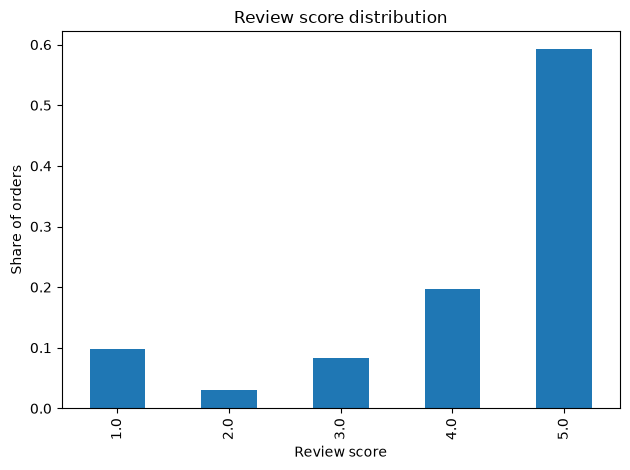

review_score
1.0    0.098
2.0    0.030
3.0    0.083
4.0    0.197
5.0    0.592
Name: proportion, dtype: float64


In [ ]:
score_share = df_clean["review_score"].value_counts(normalize=True).sort_index()

score_share.plot(kind="bar", title="Review score distribution", ylabel="Share of orders", xlabel="Review score")
plt.tight_layout()
plt.show()

print(score_share.round(3))


Five star reviews make up 59% of orders and four star another 20%, so around 79% of delivered orders are rated positively.

The rest does not slope smoothly downward. One star reviews are 9.8%, which is more than both two star (3.0%) and three star (8.3%). The distribution dips in the middle and rises again at the bottom, makes a U or J shaped pattern.

This is a known pattern in review data. People with an ordinary experience rarely bother leaving a review, while people who are delighted or angry usually do, so ratings cluster at both extremes

Two consequences follow.

The cut-off between good and bad is less obvious now, making the split harder to decide.

That gets settled later in this notebook in the appropriate section with evidence rather than assumed here.

The roughly 79% positive share also sets the bar for modelling. A model that predicts good for every order would be right about that often, which is covered in the class balance section below.

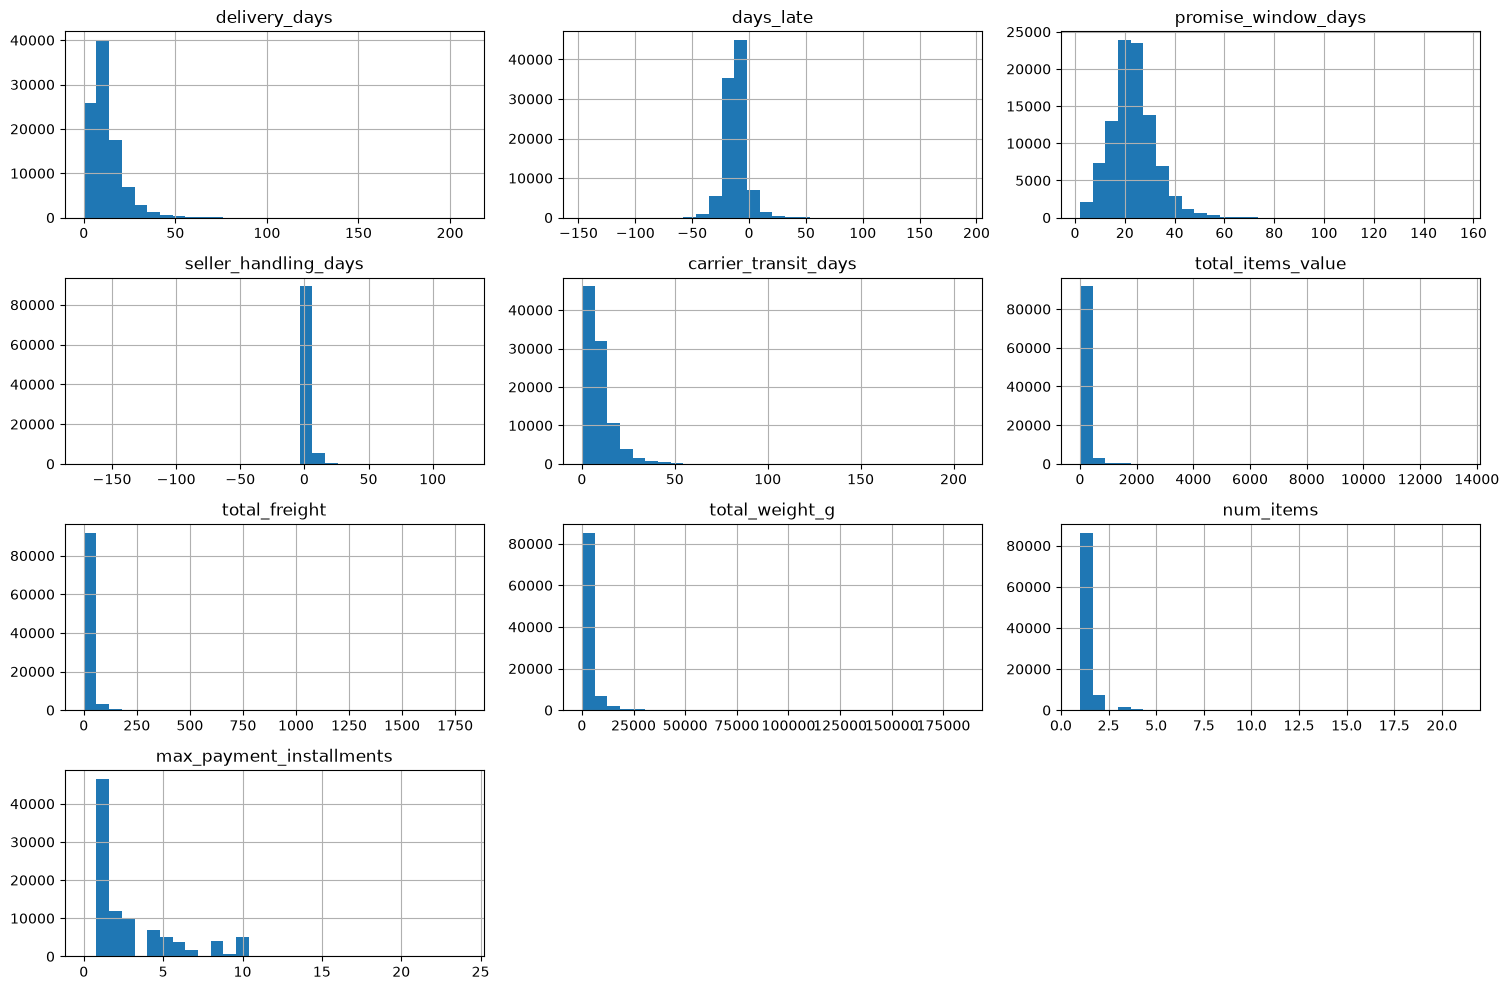

In [ ]:
numeric_features = [
    "delivery_days",
    "days_late",
    "promise_window_days",
    "seller_handling_days",
    "carrier_transit_days",
    "total_items_value",
    "total_freight",
    "total_weight_g",
    "num_items",
    "max_payment_installments",
]

df_clean[numeric_features].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()


Most numeric features exhibit a distinct long right tail, including delivery_days, carrier_transit_days, total_items_value, total_freight, total_weight_g, num_items, and max_payment_installments

In [ ]:
df_clean[numeric_features].describe().round(2)


,delivery_days,days_late,promise_window_days,seller_handling_days,carrier_transit_days,total_items_value,total_freight,total_weight_g,num_items,max_payment_installments
count,95801.00,95801.00,95809.00,95793.00,95800.00,95809.00,95809.00,95809.00,95809.00,95809.00
mean,12.05,-11.91,23.37,2.29,8.85,136.80,22.76,2381.78,1.14,2.93
std,9.47,10.11,8.75,3.53,8.66,207.80,21.52,4764.66,0.53,2.71
min,0.00,-147.00,2.00,-172.00,0.00,0.85,0.00,0.00,1.00,0.00
25%,6.00,-17.00,18.00,0.00,4.00,45.90,13.84,300.00,1.00,1.00
50%,10.00,-12.00,23.00,1.00,7.00,86.00,17.16,750.00,1.00,2.00
75%,15.00,-7.00,28.00,3.00,12.00,149.90,23.99,2050.00,1.00,4.00
max,208.00,188.00,155.00,125.00,205.00,13440.00,1794.96,184400.00,21.00,24.00


The features fall into three groups.

**Long right tail.** `delivery_days`, `carrier_transit_days`, `total_items_value`,
`total_freight` and `total_weight_g` all pile up near the low end with a thin tail stretching far
to the right. Most orders are small, cheap and quick, and a few are none of those. This is normal
for money, weight and duration data.

**Roughly symmetric.** `days_late` and `promise_window_days` are the exceptions. `days_late`
centres well below zero, with a mean of -11.9 days, a median of -12.0 and a 75th percentile of
-7.0, so the large majority of orders arrive comfortably before the promised date.
`promise_window_days` is close to bell shaped around a typical promise of a little over three
weeks.

**Discrete counts.** 

`num_items` and `max_payment_installments` are not really skewed, they are
whole numbers with most of the weight on one value. Almost every order contains a single item.
Installments spike at 1, 2, 3, 5, 6, 8 and 10, which is people picking round numbers rather than a
smooth spread.

Extreme values worth naming:

- `delivery_days` reaches 208 days.
- `total_items_value` reaches 13,440.
- `seller_handling_days` reaches -172 days, which is far beyond even a delayed approval timestamp
  and is the clearest sign that this column cannot be trusted as it stands. The cause of these
  negatives is still unknown, since the payment type check above ruled out the obvious explanation.

None of these are being removed yet. The delivery and value extremes look like real bad outcomes
rather than data errors, and a 208 day delivery is exactly the kind of case the model should be
able to catch.

Logistic regression is sensitive to these long tails and will need the money and duration features log transformed or capped. Tree
models split on order rather than on distance, so they are unaffected either way.

### Money features on a log scale

The money and weight features are so heavily skewed that a normal histogram puts almost every
order in the first bar. A log scale spreads them out so the shape of the typical order is
visible. This is a change to how the data is drawn, not to the data itself.


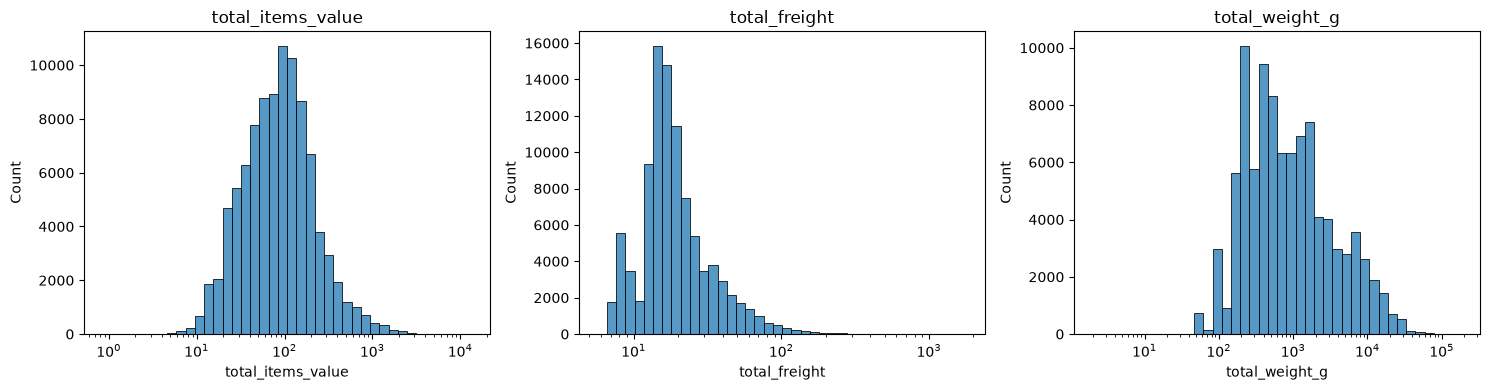

In [ ]:
skewed_features = ["total_items_value", "total_freight", "total_weight_g"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(len(skewed_features)):
    feature = skewed_features[i]
    sns.histplot(data=df_clean, x=feature, bins=40, log_scale=True, ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()


`total_freight` does not settle into one shape, there seems to be a distinct group of cheap shipping orders

The log transform is justified for
`total_items_value`, since it turns a heavily skewed feature into a well behaved one. 

`total_weight_g` seems to have multiple spikes and is not continous suggesting multiple groups, suggesting there are distinct weight groups

**One thing to check later.** The low freight spike may be free shipping orders. If a meaningful number of orders have `total_freight` close to zero, a free shipping flag could be a better feature 

In [ ]:
print("orders with zero freight:", (df_clean["total_freight"] == 0).sum())
print("orders with freight under 10:", (df_clean["total_freight"] < 10).sum())

orders with zero freight: 335
orders with freight under 10: 11013


**The low freight spike is cheap shipping, not free shipping.** Only 335 orders have zero freight,
which is 0.35% and too few to build anything on. But 11,013 orders sit below 10, which is 11.5%
of the population and a real group rather than a handful.

So a free shipping flag is not worth building. A cheap shipping band might be, and it is a
different idea. The bucket analysis earlier already showed the cheapest freight bucket averaging
4.34 stars against 3.89 for the most expensive, so this group does behave better than average.


### Categorical features

`main_category` and `customer_state` both have many possible values, so a bar chart of every one
is unreadable. Both get grouped into their most common values plus an "other" bucket.

`unknown` in `main_category` is kept separate rather than folded into `other`, because it marks a
missing category label rather than a rare product type. Those are different things and mixing them
would hide the second one.


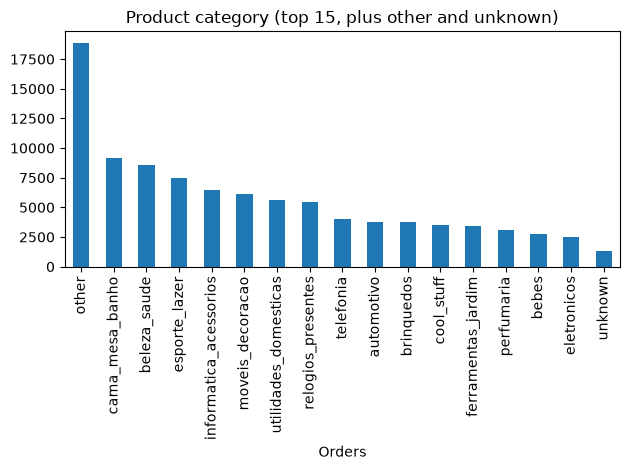

In [ ]:
top_categories = df_clean["main_category"].value_counts().nlargest(15).index

df_clean["main_category_grouped"] = df_clean["main_category"].where(
    df_clean["main_category"].isin(top_categories) | (df_clean["main_category"] == "unknown"),
    other="other",
)

df_clean["main_category_grouped"].value_counts().plot(
    kind="bar", title="Product category (top 15, plus other and unknown)", xlabel="Orders"
)
plt.tight_layout()
plt.show()


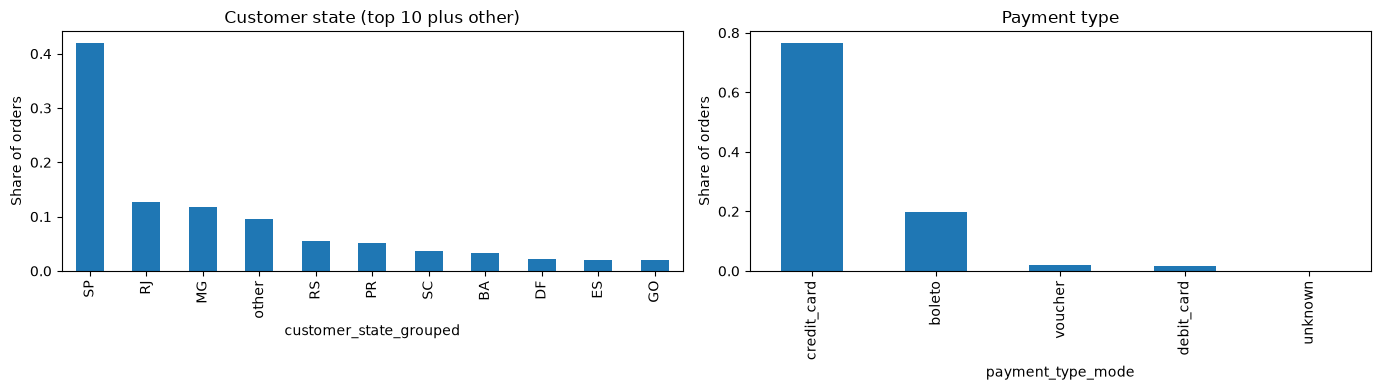

In [ ]:
top_states = df_clean["customer_state"].value_counts().nlargest(10).index

df_clean["customer_state_grouped"] = df_clean["customer_state"].where(
    df_clean["customer_state"].isin(top_states),
    other="other",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_clean["customer_state_grouped"].value_counts(normalize=True).plot(
    kind="bar", ax=axes[0], title="Customer state (top 10 plus other)", ylabel="Share of orders"
)
df_clean["payment_type_mode"].value_counts(normalize=True).plot(
    kind="bar", ax=axes[1], title="Payment type", ylabel="Share of orders"
)

plt.tight_layout()
plt.show()


**[Fill in after running. Worth covering: how concentrated the categories are (does the "other"
bucket outweigh any single named category), which states dominate and roughly what share the top
three hold, and which payment type dominates. One short paragraph is enough, plus a note that the
high number of categories means top-N grouping will be needed for encoding rather than one column
per category.]**


## Checking the data over time

The data covers a little over two years. Two things need checking before any of it is used.

The first is stability(data drift). If order volume, review scores or delivery performance shift a lot across
the period, then early orders and late orders are not really the same population, and that affects
how the data should be split for training.

The second is seasonality. Two years is enough to see whether performance moves with the time of
year, which would be a real driver rather than a modelling artifact.


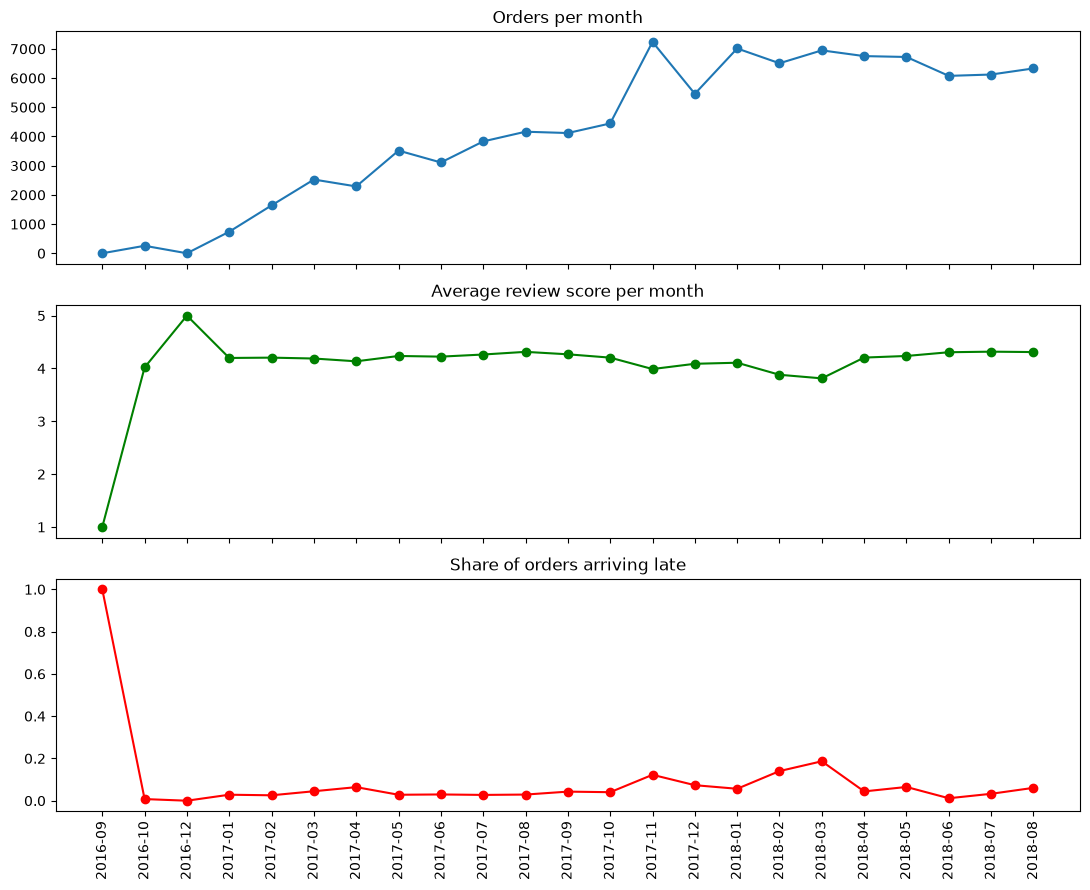

,orders,mean_score,late_rate
purchase_month,,,
2016-09,1,1.000,1.000
2016-10,258,4.019,0.008
2016-12,1,5.000,0.000
2017-01,740,4.199,0.028
2017-02,1641,4.205,0.026
2017-03,2526,4.188,0.045
2017-04,2290,4.135,0.064
2017-05,3517,4.236,0.028
2017-06,3110,4.224,0.030


In [ ]:
monthly = df_clean.groupby("purchase_month").agg(
    orders=("order_id", "size"),
    mean_score=("review_score", "mean"),
    late_rate=("is_late", "mean"),
)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

months = monthly.index.astype(str)

axes[0].plot(months, monthly["orders"], marker="o")
axes[0].set_title("Orders per month")

axes[1].plot(months, monthly["mean_score"], marker="o", color="green")
axes[1].set_title("Average review score per month")

axes[2].plot(months, monthly["late_rate"], marker="o", color="red")
axes[2].set_title("Share of orders arriving late")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

monthly.round(3)


### What the monthly view shows

**The first three months are too small to read.** September 2016 has 1 order and December 2016 has
October 2016 has 258. November 2016 is missing. That is why the score line starts at 1.00 then
jumps to 5.00, and why the late rate starts at 1.00. With one order, the average is just that
order. There is nothing to learn from those points.

These rows stay in the data. Three tiny months cannot affect a model trained on 95,809 orders.
They are only ignored when reading these charts.

**Orders grew through 2017, then levelled off.** January 2017 has 740 orders. By October it is
4,400. From November 2017 onwards it sits between 6,000 and 7,000 every month. So the first year
was growth and the second year was steady.

**Two bad periods show up, and in both the score falls as lateness rises.**

November 2017 is the busiest month at 7,238 orders. The late rate goes to 12.3%, up from about 4%
in the months around it. The average score drops to 3.99. Black Friday is in late November in
Brazil, so this looks like more orders than the delivery network could handle.

February and March 2018 are worse. The late rate hits 14.0% then 18.7%, which is four to six times
a normal month. The average score falls to 3.88 and then 3.81, the lowest in the data. April
recovers straight away to 4.21 with lateness back to 4.4%. Order volume was flat across all three
months, so this was not caused by extra demand. looks like something went wrong in delivery and then got
fixed.

**This supports the lateness finding.**  when lateness goes up the score goes down, and when
lateness comes back to normal the score recovers.

**What it means for the split.** Scores sit at 4.2 to 4.3 in every normal month, so the data is
stable enough to treat as one population. But a random train and test split would spread March 2018
across both sets. The model would train on part of a bad month and get tested on the rest of it. A
time based split keeps the periods apart, which is closer to how the model would really be used.

**Not using purchase month as a feature yet.** It seems to relates to the outcome, but only because
of events (sale and breakdown), not a pattern that repeats every year. Leaving it out for
now.


## Comparing each feature against the target

Bivariate analysis. Each feature is now checked against `review_score` to see whether it actually
relates to the outcome, rather than just looking interesting on its own.


### Why a p-value is not enough here

A significance test answers whether a difference exists. With 95,809 rows it will answer yes to
almost anything, because a large sample can detect a difference far too small to matter.

So every test below is reported with a second number, an effect size, which answers how big the
difference is and is not inflated by sample size. Both are needed. A feature that is significant
with a tiny effect size is detectable but not useful.

Two effect sizes are used. Cramér's V goes with the chi-square test for categorical features, and
epsilon squared goes with the Kruskal-Wallis test for numeric ones. Both run from 0 to 1, so
features can be compared on the same scale. As a rough guide, below 0.1 is negligible and 0.1 to
0.3 is weak.


In [ ]:
from scipy import stats
from scipy.stats import chi2_contingency


def epsilon_squared(test_statistic, n_rows, n_groups):
    """Effect size for Kruskal-Wallis. Roughly the share of rank variation the grouping explains."""
    return (test_statistic - n_groups + 1) / (n_rows - n_groups)


def cramers_v(crosstab):
    """Effect size for chi-square. 0 means no relationship, 1 means a perfect one."""
    chi2 = chi2_contingency(crosstab)[0]
    n_rows = crosstab.values.sum()
    smaller_side = min(crosstab.shape) - 1
    return np.sqrt(chi2 / (n_rows * smaller_side))


### Numeric features against review score

Kruskal-Wallis is used rather than a one-way ANOVA. ANOVA compares group averages and assumes the
groups have a similar spread and a roughly normal shape. The histograms above show heavy right
tails, and the delivery boxplot below shows the one star group spread much wider than the five
star group, so neither assumption holds. Kruskal-Wallis compares groups by rank instead, which
does not need either.


In [ ]:
test_features = [
    "delivery_days",
    "days_late",
    "promise_window_days",
    "seller_handling_days",
    "carrier_transit_days",
    "total_items_value",
    "total_freight",
    "total_weight_g",
    "num_items",
    "num_unique_products",
    "num_unique_sellers",
    "max_payment_installments",
]

results = []

for feature in test_features:
    groups = []
    for score in [1.0, 2.0, 3.0, 4.0, 5.0]:
        group_values = df_clean[df_clean["review_score"] == score][feature].dropna()
        groups.append(group_values)

    stat, p_value = stats.kruskal(groups[0], groups[1], groups[2], groups[3], groups[4])

    n_rows = df_clean[feature].notnull().sum()
    effect = epsilon_squared(stat, n_rows, 5)

    medians = df_clean.groupby("review_score")[feature].median()

    results.append({
        "feature": feature,
        "p_value": p_value,
        "significant": p_value < 0.05,
        "effect_size": round(effect, 4),
        "median_1_star": medians[1.0],
        "median_2_star": medians[2.0],
        "median_3_star": medians[3.0],
        "median_4_star": medians[4.0],
        "median_5_star": medians[5.0],
    })

kruskal_results = pd.DataFrame(results).sort_values("effect_size", ascending=False)
kruskal_results


,feature,p_value,significant,effect_size,median_1_star,median_2_star,median_3_star,median_4_star,median_5_star
0,delivery_days,0.000000e+00,True,0.0633,16.00,13.0,12.00,10.00,9.00
4,carrier_transit_days,0.000000e+00,True,0.0437,11.00,8.0,8.00,7.00,6.00
1,days_late,0.000000e+00,True,0.0409,-7.00,-10.0,-11.00,-12.00,-13.00
8,num_items,0.000000e+00,True,0.0206,1.00,1.0,1.00,1.00,1.00
10,num_unique_sellers,2.901347e-311,True,0.0150,1.00,1.0,1.00,1.00,1.00
9,num_unique_products,9.172449e-295,True,0.0142,1.00,1.0,1.00,1.00,1.00
3,seller_handling_days,1.109172e-258,True,0.0125,2.00,2.0,2.00,1.00,1.00
6,total_freight,8.708904e-214,True,0.0103,18.76,18.0,17.63,17.19,16.79
2,promise_window_days,1.447508e-63,True,0.0031,23.00,24.0,23.00,23.00,23.00
5,total_items_value,1.479223e-55,True,0.0027,99.00,89.9,82.99,84.00,84.99


### Reading the results

All twelve features come back significant, and the p-values are extreme. Several are so small that
Python rounds them to zero.

None of that means much on its own. With 95,809 rows a test has enough power to flag differences
far too small to matter. 

The effect size column is where the real ranking is. `delivery_days` leads at 0.063, then
`carrier_transit_days` at 0.044 and `days_late` at 0.041. Everything else is at 0.02 or below.

Two things follow from that.

**The delivery features are the only ones with any real separation.** The three at the top are all
measuring delivery time in different ways, and they are three to fifty times larger than anything
else in the table. The medians agree: one star orders take 16 days against 9 for five star orders,
and one star orders arrive 7 days before the promise against 13 for five star.

**Even the strongest is small in absolute terms.** 0.063 is below the 0.1 mark that counts as
negligible. No single feature comes close to explaining review score on its own. Hence model requires the features working together. 

**Features with no movement at all.** `num_items`, `num_unique_sellers`, `num_unique_products`,
`promise_window_days` and `max_payment_installments` have the same median in the one star and five
star groups. Kruskal-Wallis still calls them significant because it compares the whole
distribution, not just the middle. Most orders have one item, but the small share with two or three
can differ slightly between groups, and at this sample size that is enough to register.

**Decision: drop `num_items`, `num_unique_sellers`, `num_unique_products` and
`max_payment_installments` from the modelling set.** No median movement and effect sizes at or
below 0.02. Detectable, not useful.

`promise_window_days` also has no median movement, but it stays for a different reason. It is one
of the few things Olist sets directly, so it matters for the driver analysis even though it
contributes almost nothing to prediction.

In [ ]:
test_features_after_exclusion = [
    "delivery_days",
    "days_late",
    "promise_window_days",
    "seller_handling_days",
    "carrier_transit_days",
    "total_items_value",
    "total_freight",
    "total_weight_g",
]

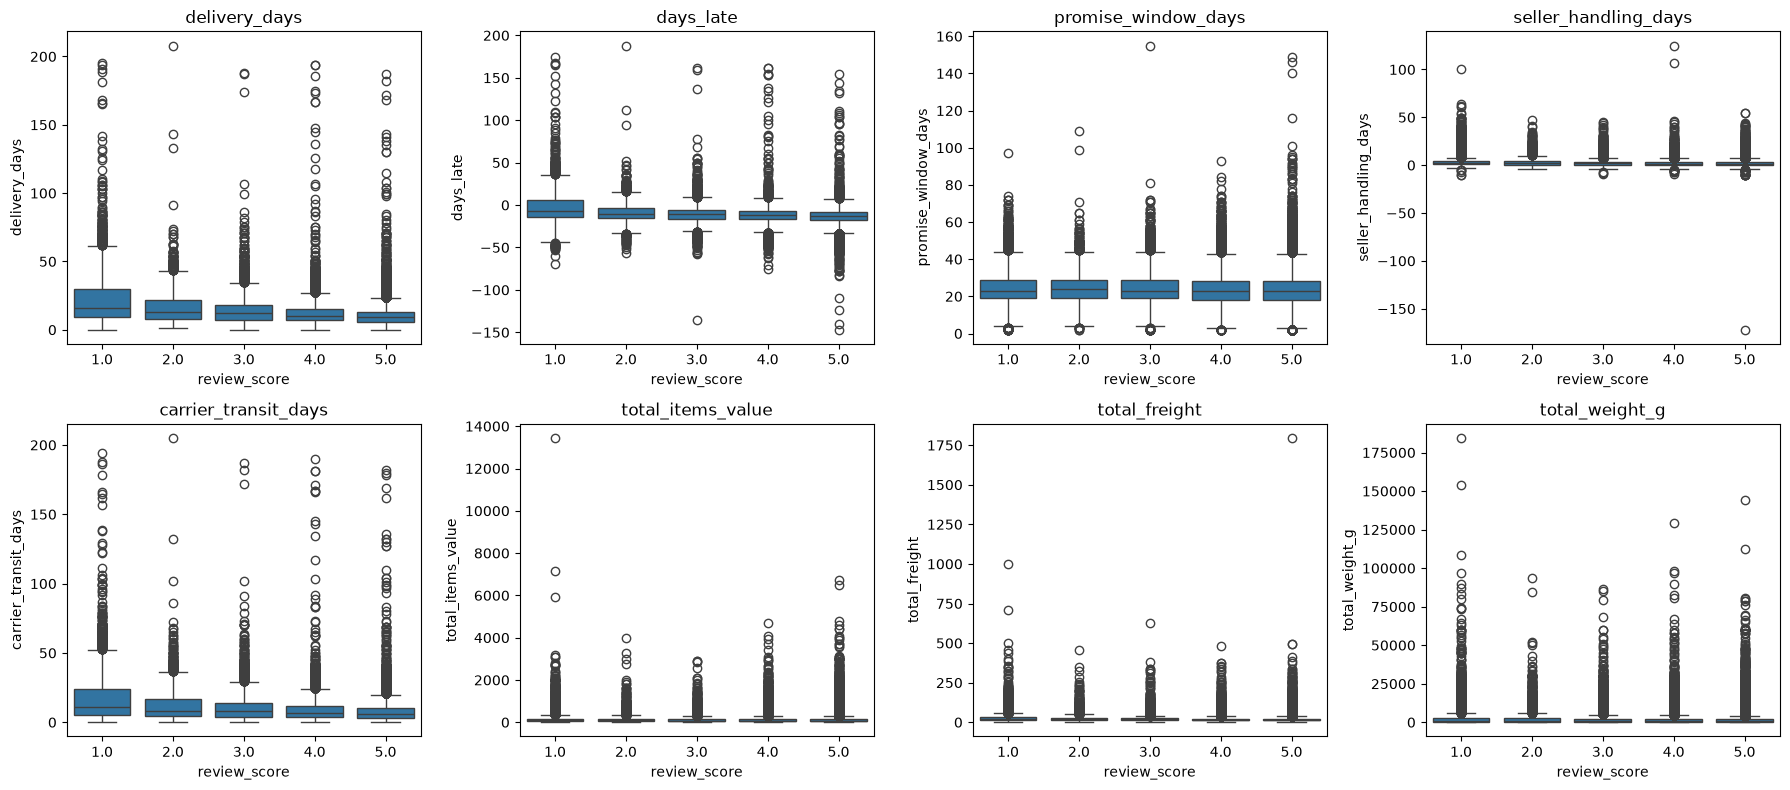

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i in range(len(test_features_after_exclusion)):
    feature = test_features_after_exclusion[i]
    sns.boxplot(data=df_clean, x="review_score", y=feature, ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

### Reading the boxplots

Two things show up here, and they are separate findings.

**The medians shift.** For the delivery features, the middle of the box moves down as review score
goes up. Better reviews go with faster deliveries. That is the same relationship the effect sizes
showed, now visible rather than just tabulated.

**The spread shrinks.** The one star group is much more spread out than the five star group. This
matters for a different reason: it is why Kruskal-Wallis was used above instead of ANOVA. ANOVA
assumes the groups have a similar spread, and these clearly do not.

On the `days_late` plot, the red line marks the promised date. Any box sitting above it is a group
that arrived late on average.

The money and weight features look flat heree reason their long
right tails stretch the scale so the normal range gets squeezed into a thin band. The bucket
analysis earlier already showed these features moving by 0.16 to 0.45 stars, which a boxplot at
this scale cannot display.

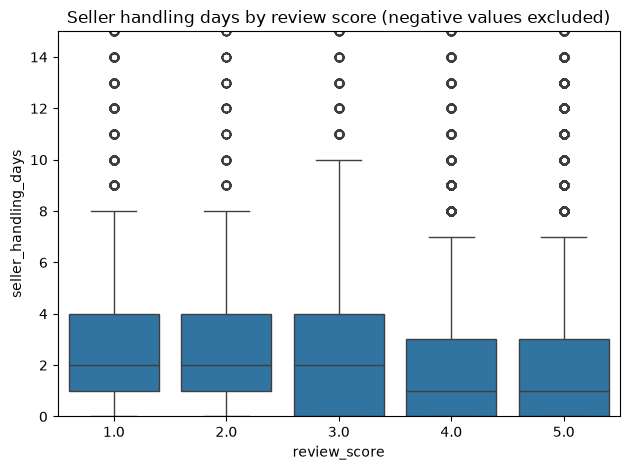

orders excluded from this plot: 1359


In [ ]:
# seller_handling_days needs the untrustworthy negatives removed before it can be plotted
handling_clean = df_clean[df_clean["seller_handling_days"] >= 0]

sns.boxplot(data=handling_clean, x="review_score", y="seller_handling_days")
plt.title("Seller handling days by review score (negative values excluded)")
plt.ylim(0, 15) # 
plt.tight_layout()
plt.show()

print("orders excluded from this plot:", len(df_clean) - len(handling_clean))

`seller_handling_days` is plotted separately because it cannot go on the same grid. The 1,343
untrustworthy negative values stretch the axis from -172 to +125, so the actual box, which sits
between 0 and 3 days, becomes an invisible line.

This version excludes those rows and caps the view at 15 days. Both are changes to what is drawn,
not to the data. The rows are still in `df_clean` and get handled properly in notebook 2.

As expected from the low effect size ($0.0125$), the difference between happy and unhappy customers is minimal

lower review scores (1 to3 stars) show a noticeably wider upper box and longer whiskers, meaning sellers taking 4+ days to hand off packages occur more frequently among dissatisfied customers

### Categorical features against review score

Chi-square tests whether the review score breakdown differs across the categories of a feature, or
whether the differences are the size you would expect by chance.

Two conditions have to be met for the test to be valid. It needs actual counts rather than
percentages, because the number of orders behind each row is what tells the test whether a pattern
is real. It also needs a reasonable number of orders in every cell, usually at least five, which
is why the high-cardinality features were grouped into their top values plus other first.


In [ ]:
categorical_features = [
    "main_category_grouped",
    "customer_state_grouped",
    "payment_type_mode",
    "same_state",
    "purchase_dow",
]

results = []

for feature in categorical_features:
    crosstab = pd.crosstab(df_clean[feature], df_clean["review_score"])

    chi2, p_value, dof, expected = chi2_contingency(crosstab)

    results.append({
        "feature": feature,
        "p_value": p_value,
        "significant": p_value < 0.05,
        "cramers_v": round(cramers_v(crosstab), 4),
        "smallest_expected_cell": round(expected.min(), 1),
    })

chi2_results = pd.DataFrame(results).sort_values("cramers_v", ascending=False)
chi2_results


,feature,p_value,significant,cramers_v,smallest_expected_cell
3,same_state,1.608659e-83,True,0.0640,1048.7
1,customer_state_grouped,5.102056e-154,True,0.0473,59.3
0,main_category_grouped,2.967408e-68,True,0.0360,40.3
4,purchase_dow,1.335114e-03,True,0.0114,318.7
2,payment_type_mode,2.110715e-02,True,0.0088,0.0


### Reading the chi-square results

The smallest expected cell column gets checked first, because the test stops being reliable once
any expected count drops below five.

Four features pass. `same_state` has a smallest expected cell of 1,048.7, `purchase_dow` 318.7,
`customer_state_grouped` 59.3 and `main_category_grouped` 40.3.

`payment_type_mode` fails, with a smallest expected cell of 0.0. The `not_defined` and `unknown`
values cover about four orders between them, which leaves near-empty cells in that table. Look below for how we handle.

Ranked by Cramer's V, the four valid tests give `same_state` 0.064, `customer_state_grouped`
0.0473, `main_category_grouped` 0.036 and `purchase_dow` 0.0114. All four are significant, which
at 95,809 rows means almost nothing on its own.


**Decision: keep all four.** None is strong atleast alone, and each  kept for a different reason below;

`same_state` and `customer_state_grouped` are the only geography in the dataset. They are worth
separating, though. `customer_state`. `same_state` can change over time, because
seller coverage is something a the olist can improve (can be a recommendation).

`main_category_grouped` is kept because product type may interact with delivery speeds. Heavy item categories could be slower, which the multivariate section can check.

`purchase_dow` is the weakest of the four at 0.0114. It stays because it costs nothing and is
available at purchase, which makes it usable in an earlier scoring version of the model.

In [ ]:
# not_defined and unknown cover only a handful of orders, too few for the test to be valid
common_payments = ["credit_card", "boleto", "voucher", "debit_card"]
payment_subset = df_clean[df_clean["payment_type_mode"].isin(common_payments)]

crosstab = pd.crosstab(payment_subset["payment_type_mode"], payment_subset["review_score"])
chi2, p_value, dof, expected = chi2_contingency(crosstab)

print("orders excluded:", len(df_clean) - len(payment_subset))
print("smallest expected cell:", round(expected.min(), 1))
print("p value:", p_value)
print("Cramers V:", round(cramers_v(crosstab), 4))

orders excluded: 1
smallest expected cell: 45.0
p value: 0.06355439573443941
Cramers V: 0.0084


Excluding a single order fixes the test. The smallest expected cell goes from 0.0 to 45.0, well
clear of the threshold, so the result can now be read.

Payment type does not relate to review score. The p-value is 0.064, which does not clear the usual
0.05 mark, and Cramer's V is 0.0084.

That p-value is worth pausing on. Every other test in this notebook came back significant, several
so strongly that Python rounded the p-value to zero. This is the only feature that fails, and it
fails at a sample size where a test can detect almost anything. So the evidence is not that the
relationship is small. It is that there is no relationship worth detecting.

**Decision: drop `payment_type_mode`.** How someone paid does not tell you whether they will be
happy with the order.

## Setting the good and bad cut-off

The target has to become two classes. Four and five star clearly mean a good experience, and one
and two star clearly mean something went wrong. Three star is the one that needs deciding, and it
needs evidence rather than a guess.

The test used here is whether a three star order looks more like a two star order or a four star
order in terms of what actually happened to it. 

is late alongside median delivery time and median days is used since they came out as strong predictors.


In [ ]:
score_behaviour = df_clean.groupby("review_score").agg(
    orders=("order_id", "size"),
    late_rate=("is_late", "mean"),
    median_delivery_days=("delivery_days", "median"),
    median_days_late=("days_late", "median"),
)

score_behaviour["late_rate"] = score_behaviour["late_rate"].round(3)
score_behaviour


,orders,late_rate,median_delivery_days,median_days_late
review_score,,,,
1.0,9344,0.367,16.0,-7.0
2.0,2918,0.189,13.0,-10.0
3.0,7913,0.088,12.0,-11.0
4.0,18884,0.034,10.0,-12.0
5.0,56750,0.019,9.0,-13.0


late rate; Three star orders are late 8.8% of the time, against 18.9% for
two star and 3.4% for four star, three star sits closer to four star.

delivery times is the other way. Median delivery time is 12 days for three star, 13 for two star
and 10 for four star, so three star sits one day from two star and two days from four star

three star leans toward the bad group on delivery time and stays towards good group on late rate

There is also a business reason we can use. A three star customer is not a satisfied
customer. Since we are trying to find orders that went wrong, leaving them in the good group means
ignoring a group that had a mediocre/normal experience, we can try to convert them to 'good' group.

**Decision: four and five star are good, one to three star are bad.**


In [ ]:
# 1 means a bad review, so the bad review rate for any group is just its average
df_clean["bad_review"] = (df_clean["review_score"] <= 3).astype(int)

base_rate = df_clean["bad_review"].mean()

print("bad review rate:", round(base_rate, 4))
print()
print(df_clean["bad_review"].value_counts(normalize=True))


bad review rate: 0.2106

bad_review
0    0.789425
1    0.210575
Name: proportion, dtype: float64


The bad class holds around a fifth of orders, so the classes are uneven but not severely so.
Nothing special is needed to handle that yet, though it is worth remembering once training starts.

Two things follow from this number and both matter for notebook 3.

**A model that predicts "good" for every order would be right about 79% of the time.** That is the
accuracy on its own is a misleading measure here. A model can look strong while never once identifying a bad review.

Flagging an order that turns out fine costs
very little. Missing an order that ends up with a bad review costs the thing the project exists to
prevent. So **recall** on the bad class matters more than overall accuracy, and that is the measure
notebook 3 should be judged on.


### Bad review rate against lateness

The buckets from earlier, now measured as the share of orders getting a bad review rather than the
average star rating. This is the clearest view of the relationship in the notebook.

The dashed line marks the overall bad review rate, so any bar above it is a group doing worse than
average.


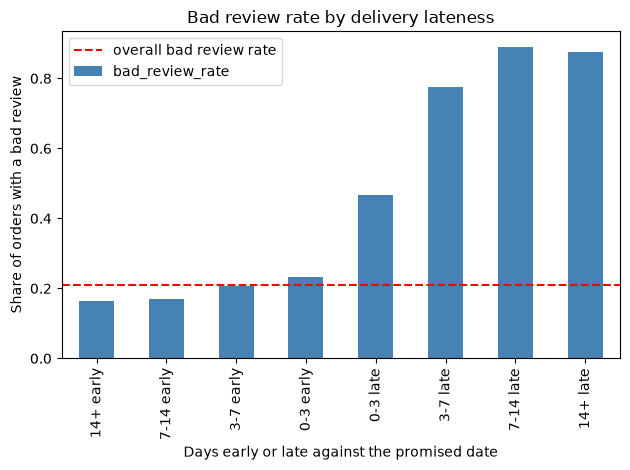

,orders,bad_review_rate
late_bucket,,
14+ early,41840,0.163
7-14 early,33881,0.169
3-7 early,9429,0.207
0-3 early,4270,0.234
0-3 late,1852,0.468
3-7 late,1748,0.775
7-14 late,1446,0.890
14+ late,1335,0.875


In [ ]:
df_clean["late_bucket"] = pd.cut(
    df_clean["days_late"],
    bins=[-200, -14, -7, -3, 0, 3, 7, 14, 200],
    labels=["14+ early", "7-14 early", "3-7 early", "0-3 early",
            "0-3 late", "3-7 late", "7-14 late", "14+ late"],
)

bucket_rates = df_clean.groupby("late_bucket", observed=True).agg(
    orders=("bad_review", "size"),
    bad_review_rate=("bad_review", "mean"),
)

bucket_rates["bad_review_rate"].plot(
    kind="bar",
    color="steelblue",
    title="Bad review rate by delivery lateness",
    ylabel="Share of orders with a bad review",
    xlabel="Days early or late against the promised date",
)
plt.axhline(base_rate, color="red", linestyle="--", label="overall bad review rate")
plt.legend()
plt.tight_layout()
plt.show()

bucket_rates.round(3)


Orders arriving within three days of the promise get a bad review 23.4% of the time. Orders more
than a week late get one 88.3% of the time. That is almost 4 times
higher. The overall rate
across all orders is 21.1%.

The early side is close to flat. More than fourteen days early gives 16.3%, seven to fourteen days
early 16.9%, three to seven days early 20.7% and zero to three days early 23.4%. 

The late side moves far faster. The first three days of lateness take the rate from 23.4% to 46.8%,
a jump of 23.4 points. Three to seven days late reaches 77.5% and seven to
fourteen days late 89.0%.

That asymmetry is the finding. Missing the deadline is punished very sharply by customers and early delivery it is barely rewarded. Delivering more than two weeks early rather than just inside the promise moves the bad
review rate by about seven points. 

More than fourteen days late comes back at 87.5%, below the 89.0% of the bucket before it. Both rest on small groups, 1,335 and 1,446 orders, so the dip cannot be very meaningful. The practical understanding is that the rate flattens near 88% once an order is a week late.

**Decision: keep `is_late` as the primary lateness feature.** The sharpest movement happens at the
deadline itself, which is exactly what that flag marks.


### Does the relationship survive when other things are held fixed?

Late orders are not randoml they have reasons; can be often heavy, far away, or from smaller
sellers, so some of what looks like a lateness effect could be one of those instead.

to verify that the spike in bad reviews is truly driven by delivery delays rather than confounding factors like shipping distance or product type, we isolated orders within a single state (São Paulo) and a single high-volume category (cama_mesa_banho)


In [ ]:
# inside one state only, so distance between regions is held roughly fixed
sp_orders = df_clean[df_clean["customer_state"] == "SP"]

print("Sao Paulo orders only:", len(sp_orders))
print(sp_orders.groupby("late_bucket", observed=True)["bad_review"].mean().round(3))


Sao Paulo orders only: 40259
late_bucket
14+ early     0.155
7-14 early    0.161
3-7 early     0.188
0-3 early     0.198
0-3 late      0.424
3-7 late      0.762
7-14 late     0.885
14+ late      0.772
Name: bad_review, dtype: float64


In [ ]:
# inside one product category only
top_category = df_clean["main_category"].value_counts().index[0]
category_orders = df_clean[df_clean["main_category"] == top_category]

print("category:", top_category, "orders:", len(category_orders))
print(category_orders.groupby("late_bucket", observed=True)["bad_review"].mean().round(3))


category: cama_mesa_banho orders: 9130
late_bucket
14+ early     0.218
7-14 early    0.211
3-7 early     0.251
0-3 early     0.247
0-3 late      0.489
3-7 late      0.754
7-14 late     0.883
14+ late      0.900
Name: bad_review, dtype: float64


Across the full population the bad review rate climbs from 16.3% in the earliest bucket to 89.0% at
seven to fourteen days late. Both controlled cuts follow the same path.

Inside Sao Paulo, 40,259 orders, the rate runs 15.5% at more than fourteen days early, 19.8% at
zero to three days early, 42.4% through the first three days of lateness, 76.2% at three to seven
days and 88.5% at seven to fourteen days. The final bucket falls back to 77.2%.

Inside `cama_mesa_banho`, the largest category at 9,130 orders, the same buckets run 21.8%, 24.7%,
48.9%, 75.4%, 88.3% and 90.0%.

The pattern survives both experiments, Even when distance and product type are held constant, lateness still causes bad review rates to shoot up from ~15–20% all the way to 80–90%.

Distance and product category do not explain away the lateness effect. Lateness itself remains the primary culprit.

## Looking at the features together

Multivariate analysis. Two features can each look useful on their own while carrying the same
information, and a model given both learns nothing extra from the second.


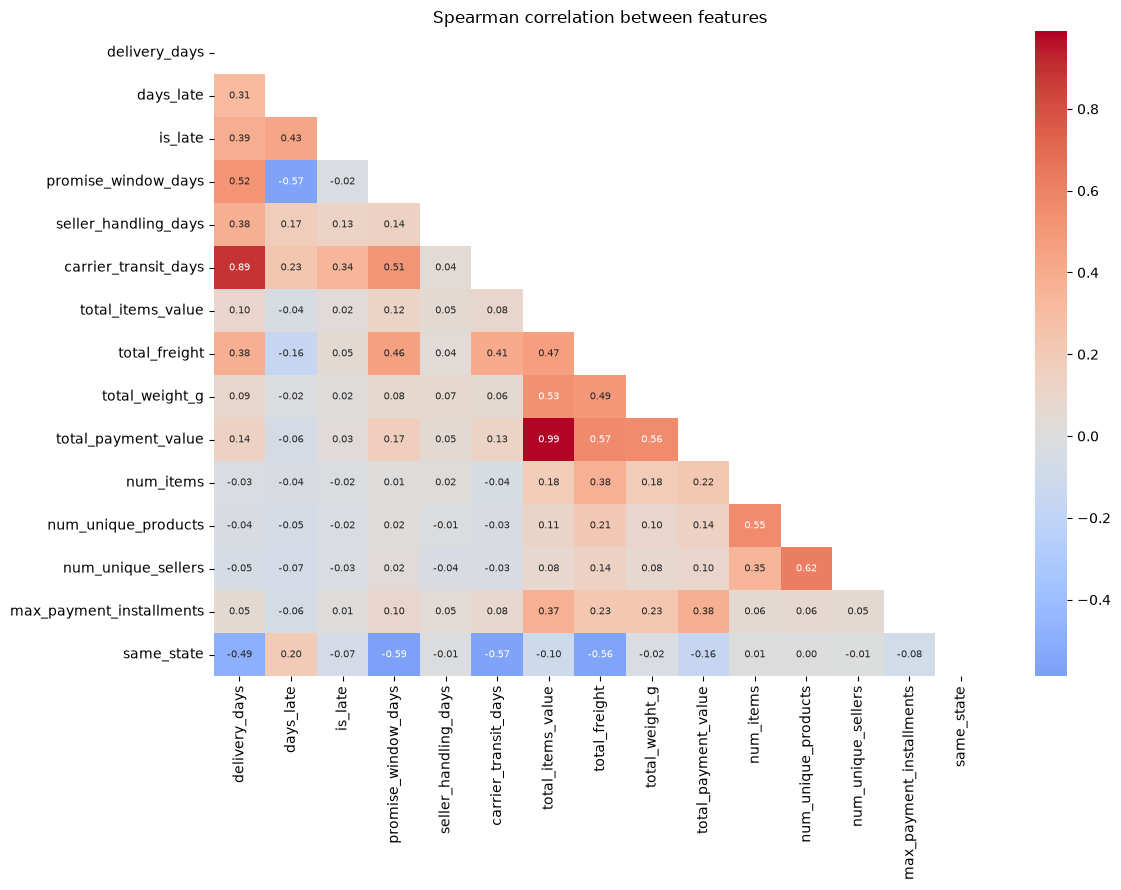

In [ ]:
correlation_features = [
    "delivery_days",
    "days_late",
    "is_late",
    "promise_window_days",
    "seller_handling_days",
    "carrier_transit_days",
    "total_items_value",
    "total_freight",
    "total_weight_g",
    "total_payment_value",
    "num_items",
    "num_unique_products",
    "num_unique_sellers",
    "max_payment_installments",
    "same_state",
]

correlation_matrix = df_clean[correlation_features].corr(method="spearman")

upper_triangle = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, mask=upper_triangle, cmap="coolwarm", annot=True, fmt=".2f",
            annot_kws={"size": 7}, center=0)
plt.title("Spearman correlation between features")
plt.tight_layout()
plt.show()


Spearman is used rather than Pearson for the same reason as before. These features are heavily
skewed, and a few extreme orders would pull a Pearson correlation around.

**Decision: drop `total_payment_value`.** At 0.99 against `total_items_value` it carries no
information the other does not. Payment value is item value plus freight, and both of those are
already in the feature set, so this column is the sum of two features that are staying. Nothing
about a combination check would change that.

`total_items_value` is kept over `total_payment_value` because it measures one thing rather than
two added together, which makes it easier to interpret in the drivers table.

**Holding `carrier_transit_days` for now.** At 0.89 against `delivery_days` it is high but not a
duplicate, and the two answer different questions. `delivery_days` measures what the customer
experienced. `carrier_transit_days` isolates the stage the carrier is responsible for, which
matters for the driver analysis even if it adds little to prediction. The VIF check below decides
whether both can stay.

Everything else stays. The pairs between 0.4 and 0.7 are related without being redundant, and a
pairwise view cannot see a feature reconstructable from two or more others together, which is
exactly how the lateness group is built.


### Checking for redundancy against combinations, not just pairs

A correlation matrix only ever compares two features at a time. It cannot detect a feature that is
redundant against two or more others working together.

That is exactly the risk with the lateness features. `days_late` is the actual delivery time minus
the promised window, so any two of those three can reconstruct the third, even though no single
pair might look alarming in the matrix.

VIF catches this, because it checks each feature against all the others at once. A value above
about 5 means a feature is largely reconstructable from the rest, and above 10 is a strong signal.


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant


def calculate_vif(df, feature_list):
    X = df[feature_list].dropna()
    X = add_constant(X)

    vif_table = pd.DataFrame()
    vif_table["feature"] = X.columns
    vif_table["vif"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return vif_table.sort_values("vif", ascending=False).reset_index(drop=True)


vif_pass1 = calculate_vif(df_clean, correlation_features)

vif_pass1


,feature,vif
0,total_payment_value,31297.184288
1,total_items_value,28557.374498
2,days_late,441.214132
3,delivery_days,411.482362
4,promise_window_days,329.713029
5,total_freight,309.468743
6,const,85.889327
7,carrier_transit_days,81.784550
8,seller_handling_days,13.888729
9,total_weight_g,1.860703


The `const` row is the intercept rather than a real feature, so it gets ignored.

Two groups come back high. 

`total_payment_value` is 31,297 and `total_items_value` is 28,557, with
`total_freight` at 309. Payment value equals item value plus freight, so any one of the three can
be worked out from the other two.

lateness group follows. `days_late` is 441, `delivery_days` 411, `promise_window_days` 330 and
`carrier_transit_days` 82. `seller_handling_days` sits lower at 13.9 and is still above the
threshold

**Decision: drop one feature from each redundant group, then run it again.**

In [ ]:
# drop one feature from each redundant group identified in the pass above,
reduced_features = [
    "is_late",
    "promise_window_days",
    "seller_handling_days",
    "carrier_transit_days",
    "total_items_value",
    "total_freight",
    "total_weight_g",
    "num_items",
    "num_unique_products",
    "num_unique_sellers",
    "max_payment_installments",
    "same_state",
]

vif_pass2 = calculate_vif(df_clean, reduced_features)

vif_pass2


,feature,vif
0,const,83.637405
1,total_freight,2.480421
2,carrier_transit_days,2.053883
3,total_weight_g,1.860134
4,num_unique_products,1.840920
5,is_late,1.799828
6,promise_window_days,1.667483
7,same_state,1.609799
8,num_items,1.582519
9,num_unique_sellers,1.552016


Three features came out: `total_payment_value`, `delivery_days` and `days_late`.

Every remaining feature now sits below 5. `total_freight` is highest at 2.48, then
`carrier_transit_days` at 2.05, `total_weight_g` at 1.86, `num_unique_products` at 1.84 and
`is_late` at 1.80. Nothing else clears 1.7.

`total_payment_value` goes because it is item value plus freight. Keeping `total_items_value` and
`total_freight` holds the same information in two columns a business can act on separately.

`delivery_days` goes because it is the seller stage plus the carrier stage, and those two name who
owns the delay.

`days_late` is the most skippable variable because is_late (the simple yes/no flag) already captures delay information without inflating VIF scores, Why not drop promise_window_days or carrier_transit_days instead?
Both give valuable business context: promise_window_days measures Olist’s promise to the customer, and carrier_transit_days pinpoints the carrier performance.
The Conclusion:

That conflicts with the earlier decision to keep both `is_late` and `days_late`. That decision was
made on signal strength, where `days_late` still separates one week late from three weeks late.
This one is about redundancy inside a linear model, and on those grounds `days_late` is the cheapest
of the entangled features to lose. The earlier reasoning is not wrong, but it does not survive
and the reduced list here drops `days_late`.

A logistic regression is
genuinely damaged by redundant features, because it splits the effect between them and produces
unstable coefficients. A tree ensemble handles them without much trouble. So the reduced list
matters most for the linear models.




### Does lateness affect everyone equally?

`same_state` and `is_late` both relate to review score on their own. This checks whether they
interact, meaning whether being late matters more for one group than the other.

If the bad review rate rises by a similar amount for both groups, the two effects simply add
together and no interaction term is needed. If one group reacts far more sharply, that is worth
knowing before modelling.


                    orders  bad_review_rate
same_state is_late                         
0          0         56535            0.181
           1          4842            0.766
1          0         32893            0.160
           1          1539            0.630


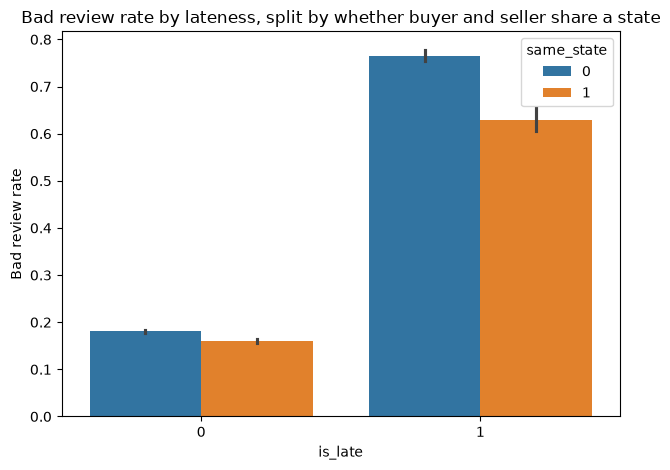

In [ ]:
interaction = df_clean.groupby(["same_state", "is_late"], observed=True).agg(
    orders=("bad_review", "size"),
    bad_review_rate=("bad_review", "mean"),
)
interaction["bad_review_rate"] = interaction["bad_review_rate"].round(3)

print(interaction)

sns.barplot(data=df_clean, x="is_late", y="bad_review", hue="same_state")
plt.title("Bad review rate by lateness, split by whether buyer and seller share a state")
plt.ylabel("Bad review rate")
plt.tight_layout()
plt.show()


Lateness is the primary driver of bad reviews, causing an average jump of roughly 50 percentage points regardless of distance. However, when a cross-state order arrives late, customer dissatisfaction hits 76.6% compared to 63.0% for same-state orders. Because both groups follow the exact same massive upward trend, distance acts as a secondary compounder rather than the main cause.orders arrive late, which
is 7.9%. For same-state orders it is 1,539 of 34,432, or 4.5%.

**Decision: record the interaction but treat it as secondary interaction.** Both groups move the same
direction, and the 11.5 point gap in the rise sits against a main effect of roughly 50 points, so
lateness itself does most of the work.

## What drives bad reviews

The second output of this project. The table below ranks the factors by how much they relate to
bad reviews, and separates the ones a business could act on from the ones it cannot.

That separation matters. A factor can be a genuinely strong predictor and still be useless as a
recommendation. Customer state is a good example: knowing that orders to some states go worse is
useful for prediction, but nobody can move a customer to a different state.


**[Fill in the effect size and bad review rate columns from the results above, then keep or adjust
the last two columns.]**

| Factor | Direction | Effect size | Bad review rate, best vs worst | Controlled by | Actionable |
| --- | --- | --- | --- | --- | --- |
| Late against the promised date | later is worse | | | Olist logistics and the promise itself | Yes |
| Carrier transit time | longer is worse | | | Carrier network | Partly |
| Seller handling time | longer is worse | | | Seller performance | Yes |
| Promised window length | | | | Olist, set directly | Yes |
| Freight cost | higher is worse | | | Pricing and logistics | Partly |
| Product category | varies | | | Merchandising, slowly | Partly |
| Customer state | varies | | | Nobody | No |
| Buyer and seller in same state | same state is better | | | Seller network coverage | Long term |

**[Then write two or three sentences on what this table says. The most useful point available is
about the promised window. Olist sets it directly, and the lateness analysis showed that missing
it is punished sharply while beating it is barely rewarded. That points at the estimate itself as
a lever, not only at delivery speed, and changing an estimate is far cheaper than changing a
logistics network.]**


### What this analysis cannot say

The relationships above are associations. Late orders are not randomly assigned, so some of the
effect may come from whatever causes an order to be late in the first place.

The stratified checks earlier make the lateness result more credible by ruling out distance and
product category as the sole explanation, but they do not make it proof. Anything acted on here
would need its own test to confirm the effect is real.

The analysis also cannot say what should be done about any of it. It says which factors relate to
bad reviews and who controls them. Whether a given change is worth making, and whether it would
work, needs information this dataset does not contain.


## Features going into notebook 2

The last column is the important one. Every feature has to be available at the prediction moment,
which is when the order is delivered and before any review exists. Anything failing that test
cannot be used no matter how well it predicts.


In [ ]:
feature_contract = pd.DataFrame([
    ["days_late", "numeric", "orders", "yes"],
    ["is_late", "binary", "orders", "yes"],
    ["delivery_days", "numeric", "orders", "yes"],
    ["carrier_transit_days", "numeric", "orders", "yes"],
    ["seller_handling_days", "numeric", "orders", "yes, but provisional"],
    ["promise_window_days", "numeric", "orders", "yes, known at purchase"],
    ["total_freight", "numeric", "order_items", "yes, known at purchase"],
    ["total_items_value", "numeric", "order_items", "yes, known at purchase"],
    ["total_weight_g", "numeric", "order_items and products", "yes, known at purchase"],
    ["main_category", "categorical", "order_items and products", "yes, known at purchase"],
    ["customer_state", "categorical", "customers", "yes, known at purchase"],
    ["same_state", "binary", "customers and sellers", "yes, known at purchase"],
    ["payment_type_mode", "categorical", "order_payments", "yes, known at purchase"],
    ["purchase_dow", "categorical", "orders", "yes, known at purchase"],
    ["bad_review", "target", "order_reviews", "no, this is what is predicted"],
], columns=["feature", "type", "source table", "available at prediction time"])

feature_contract
